# tafmSSD — Análise Comparativa Completa

Compara o portfólio **tafmSSD** contra todos os modelos da família SSD:

| Modelo | Benchmark de otimização |
|--------|------------------------|
| **scSSD** | SP500 (único) |
| **scmSSD SP500** | SP500 (multi-bench com 1 benchmark) |
| **scmSSD CMA / HML / MARKET / RMW / SMB** | Factor Fama-French individual |
| **tafmSSD** | Benchmark sintético = max_k(cumsum sorted) |

**Pré-requisito:**
```bash
python src/scSSD.py
python src/scmSSD.py --benchmarks all
python src/tafmSSD.py --benchmarks all
```

**Estrutura:**
1. Setup
2. Carregamento de dados e modelos
3. Contexto de mercado
4. Benchmark sintético OOS
5. Visão geral — todos os modelos
6. scmSSD por fator vs tafmSSD
7. Drawdown comparativo
8. Métricas OOS — tabela completa
9. Dominância SSD — modelo vs seu benchmark
10. Análise risco × retorno
11. Distribuição e correlação
12. Retornos em janela deslizante
13. Sumário executivo


---
## 1. Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

warnings.filterwarnings('ignore')

ROOT         = Path('..').resolve()
SRC          = ROOT / 'src'
OUTPUT_DIR   = SRC / 'output'
TAFMSSD_DIR  = OUTPUT_DIR / 'tafmssd'
SCMSSD_DIR   = OUTPUT_DIR / 'scmssd'
SCSSD_DIR    = OUTPUT_DIR / 'scssd'
DATA_DIR     = SRC / 'data'

sys.path.insert(0, str(SRC))
from metrics.stats import compute_ssd_dominance, compute_metrics
from blotter.plots import (
    plot_market_context, plot_performance,
    plot_dominance_overview, plot_dominance_panels,
    plot_risk_return_scatter, plot_return_distribution,
    plot_correlation_matrix, plot_drawdown, plot_rolling_returns,
    plot_portfolio_comparison,
)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top':  False,   'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 12,
})

AVAILABLE_BENCHMARKS = ['SP500', 'CMA', 'HML', 'MARKET', 'RMW', 'SMB']
FACTOR_BENCHMARKS    = ['CMA', 'HML', 'MARKET', 'RMW', 'SMB']
OOS_START  = '2024-01-01'
OOS_END    = '2024-06-01'
RISK_FREE  = 0.05

print(f'ROOT: {ROOT}')


ROOT: /media/toni/Dados/Git/ssd-multi


---
## 2. Carregamento de dados e modelos

In [2]:
# ── Market data ───────────────────────────────────────────────────
market        = pd.read_csv(DATA_DIR / 'marketData.csv', parse_dates=['Date'])
market.set_index('Date', inplace=True)
market_prices = market.dropna(how='all').abs()

market_returns = market_prices.diff() / market_prices.shift(1)
factors_df     = pd.read_csv(DATA_DIR / 'factors.csv')
market_returns[factors_df.columns] = factors_df.to_numpy()
market_returns = market_returns.iloc[1:]

print(f'Market data  : {market_prices.shape}')

# ── OOS benchmark series ──────────────────────────────────────────
bench_data = {}

sp500_oos = market_prices.loc[OOS_START:OOS_END, 'SP500']
bench_data['SP500'] = {
    'norm': sp500_oos / sp500_oos.iloc[0],
    'ret':  market_returns.loc[OOS_START:OOS_END, 'SP500'],
}
for b in FACTOR_BENCHMARKS:
    ret = market_returns.loc[OOS_START:OOS_END, b]
    cum = (1 + ret).cumprod()
    bench_data[b] = {'norm': cum / cum.iloc[0], 'ret': ret}

idx        = bench_data['SP500']['norm'].index
sp500_norm = bench_data['SP500']['norm']
print(f'OOS          : {idx[0].date()} → {idx[-1].date()}  ({len(idx)} dias)')

# ── Load all model portfolios ─────────────────────────────────────
def load_port(path, label):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    s  = df.iloc[:, 0].reindex(idx).ffill()
    return s.rename(label)

models = {}  # {label: Series}

# scSSD (single-benchmark SP500, classic)
scssd_path = SCSSD_DIR / 'portfolio_scssd.csv'
if scssd_path.exists():
    models['scSSD'] = load_port(scssd_path, 'scSSD')

# scmSSD per-benchmark
SCMSSD_BENCHES = ['sp500', 'cma', 'hml', 'market', 'rmw', 'smb']
for b in SCMSSD_BENCHES:
    path = SCMSSD_DIR / b / f'portfolio_scmssd_{b}.csv'
    if path.exists():
        models[f'scmSSD {b.upper()}'] = load_port(path, f'scmSSD {b.upper()}')

# tafmSSD (synthetic benchmark)
taf_path = TAFMSSD_DIR / 'portfolio_tafmssd.csv'
if taf_path.exists():
    models['tafmSSD'] = load_port(taf_path, 'tafmSSD')

# OOS synthetic benchmark
synth_oos = pd.read_csv(TAFMSSD_DIR / 'synthetic_benchmark_oos.csv',
                         index_col=0, parse_dates=True).squeeze().reindex(idx).ffill()

print(f'\nModelos carregados ({len(models)}):')
for k, v in models.items():
    print(f'  {k:<22}  final = {v.iloc[-1]:.4f}  ({(v.iloc[-1]-1)*100:+.2f}%)')


Market data  : (305, 509)
OOS          : 2024-01-02 → 2024-05-31  (105 dias)

Modelos carregados (8):
  scSSD                   final = 1.4911  (+49.11%)
  scmSSD SP500            final = 1.4911  (+49.11%)
  scmSSD CMA              final = 1.1270  (+12.70%)
  scmSSD HML              final = 1.3917  (+39.17%)
  scmSSD MARKET           final = 1.5458  (+54.58%)
  scmSSD RMW              final = 1.2423  (+24.23%)
  scmSSD SMB              final = 1.4568  (+45.68%)
  tafmSSD                 final = 1.2230  (+22.30%)


---
## 3. Contexto de mercado — todos os benchmarks

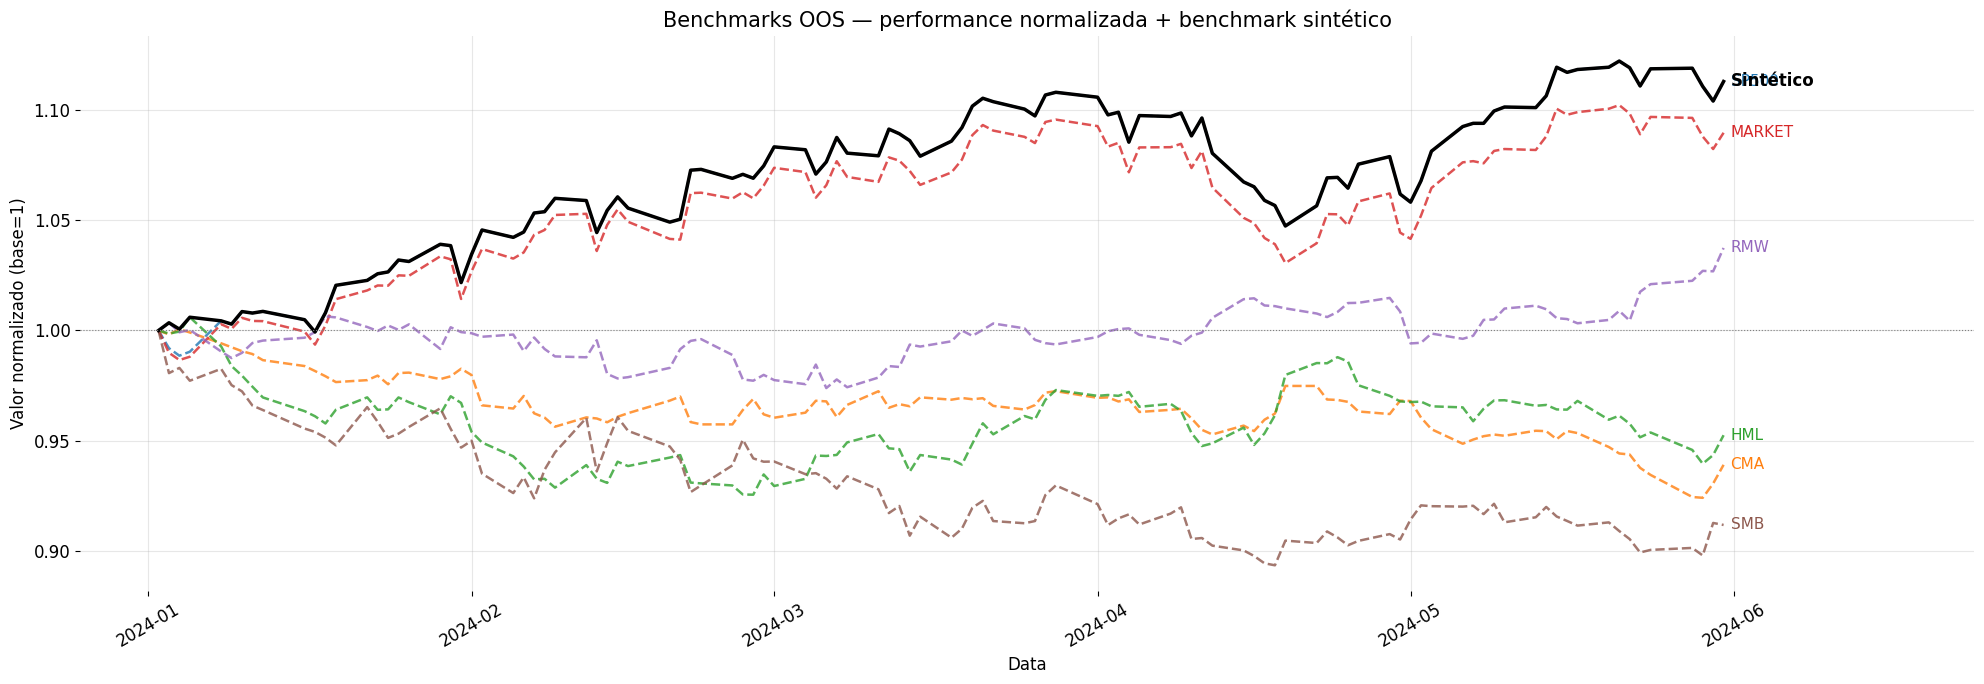

In [3]:
fig, ax = plt.subplots(figsize=(20, 7))
colors  = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, (b, d) in enumerate(bench_data.items()):
    norm  = d['norm']
    color = colors[i % len(colors)]
    ax.plot(norm.index, norm.values, linewidth=1.8, linestyle='--', color=color, alpha=0.8)
    ax.annotate(b, xy=(norm.index[-1], norm.iloc[-1]),
                xytext=(5, 0), textcoords='offset points', va='center',
                fontsize=11, color=color)

ax.plot(synth_oos.index, synth_oos.values, linewidth=2.5, color='black')
ax.annotate('Sintético', xy=(synth_oos.index[-1], synth_oos.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center',
            fontsize=12, color='black', fontweight='bold')

ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.10)
ax.set_title('Benchmarks OOS — performance normalizada + benchmark sintético', fontsize=15)
ax.set_xlabel('Data'); ax.set_ylabel('Valor normalizado (base=1)')
ax.tick_params(axis='x', rotation=30)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(TAFMSSD_DIR / 'benchmarks_overview.pdf', bbox_inches='tight')
plt.show()


[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/market_context_sp500.pdf


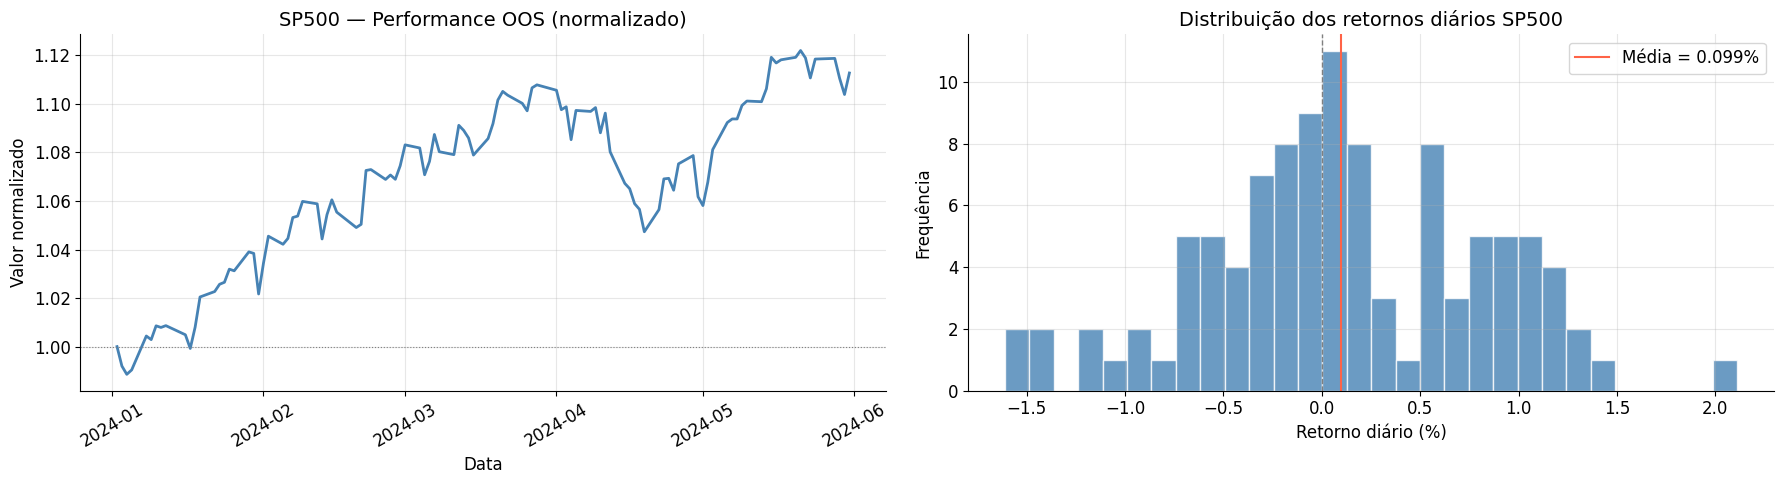

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/market_context_cma.pdf


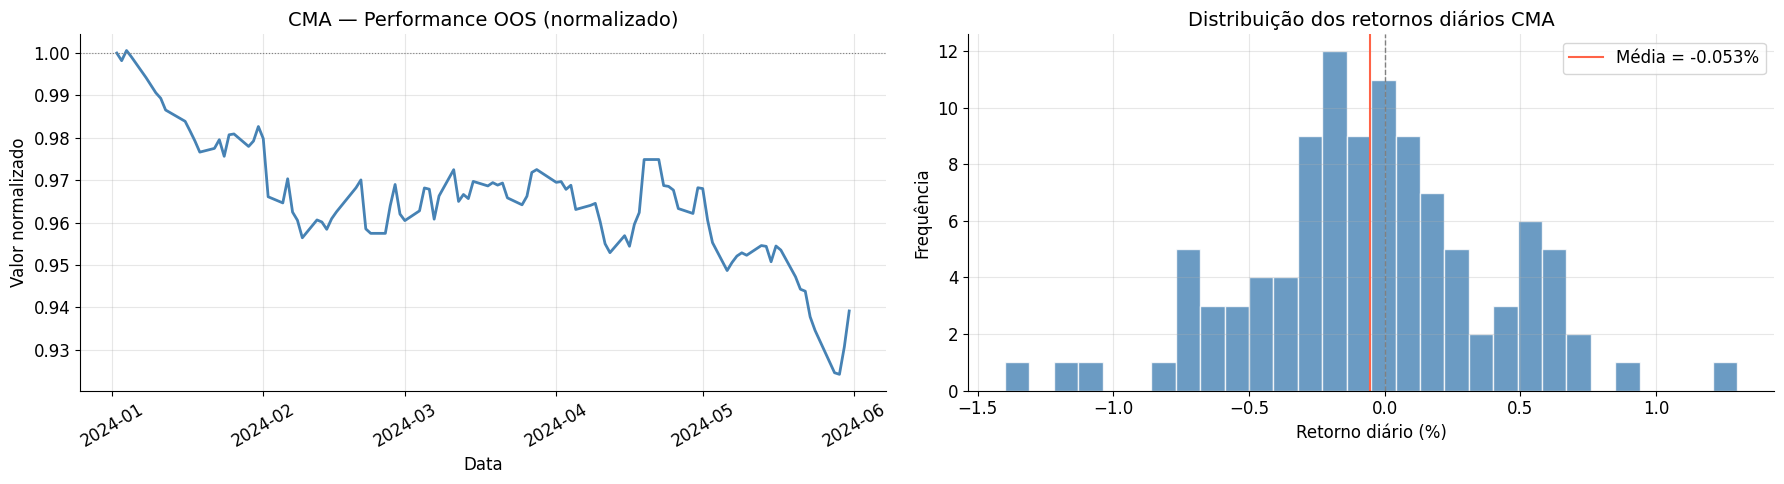

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/market_context_hml.pdf


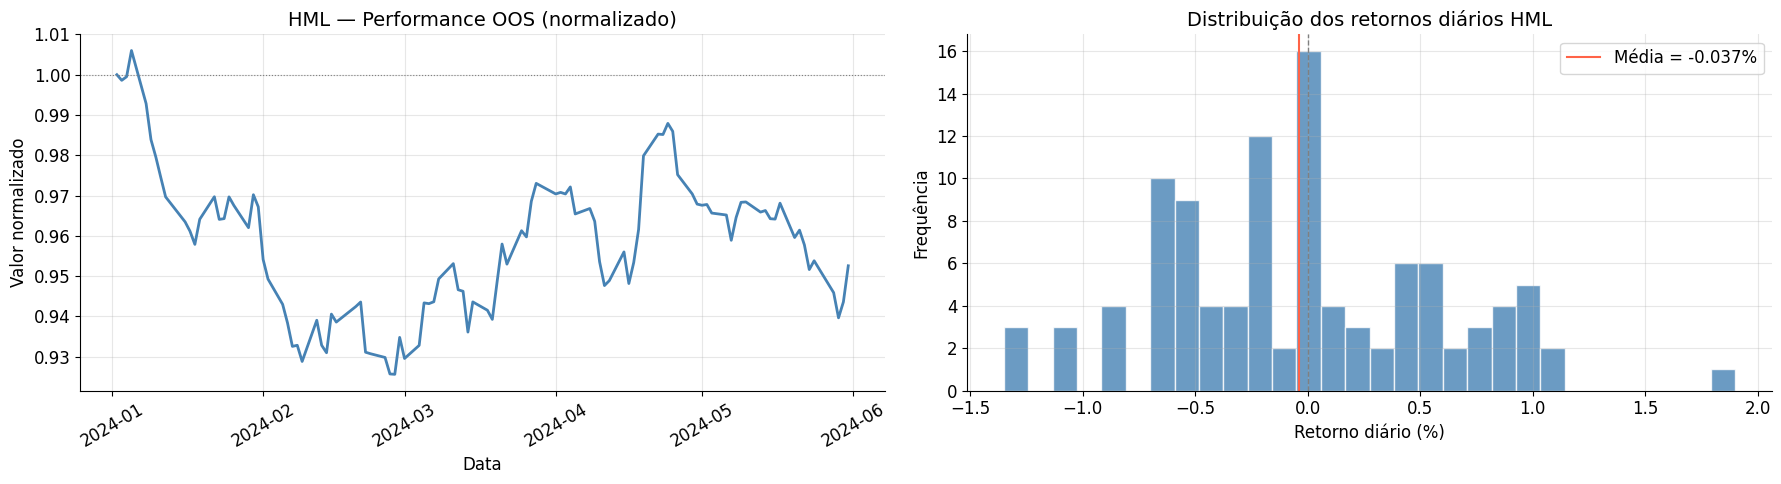

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/market_context_market.pdf


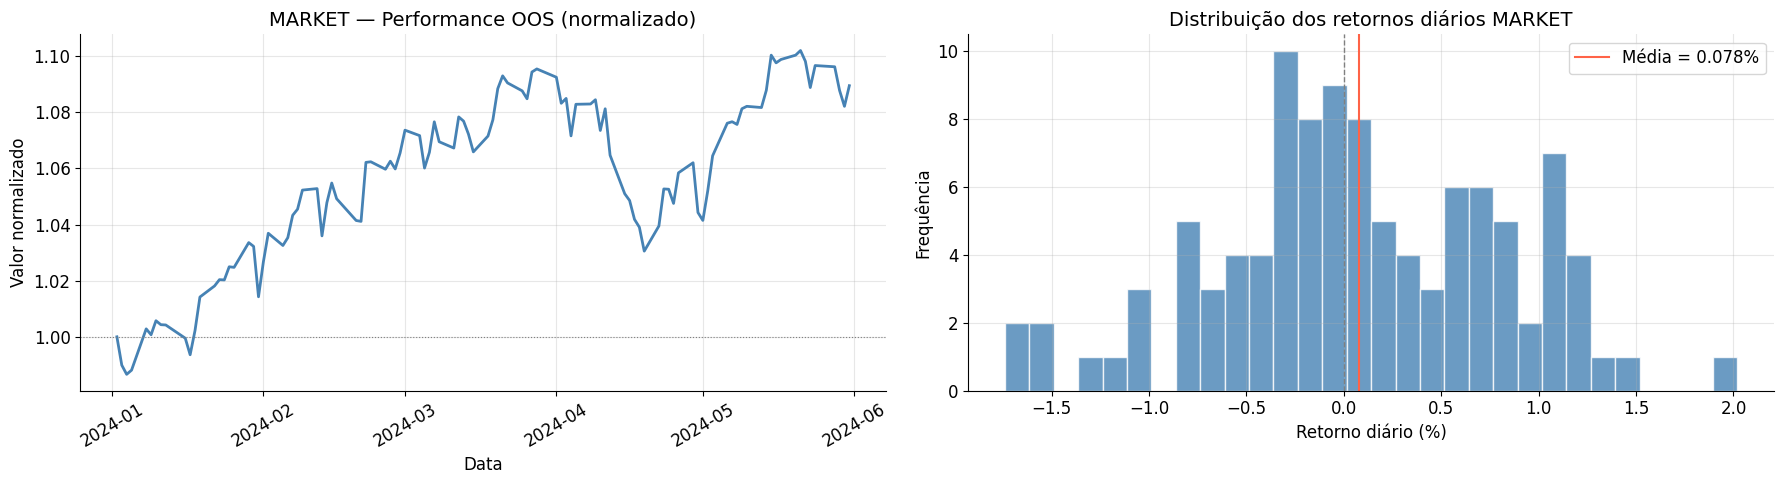

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/market_context_rmw.pdf


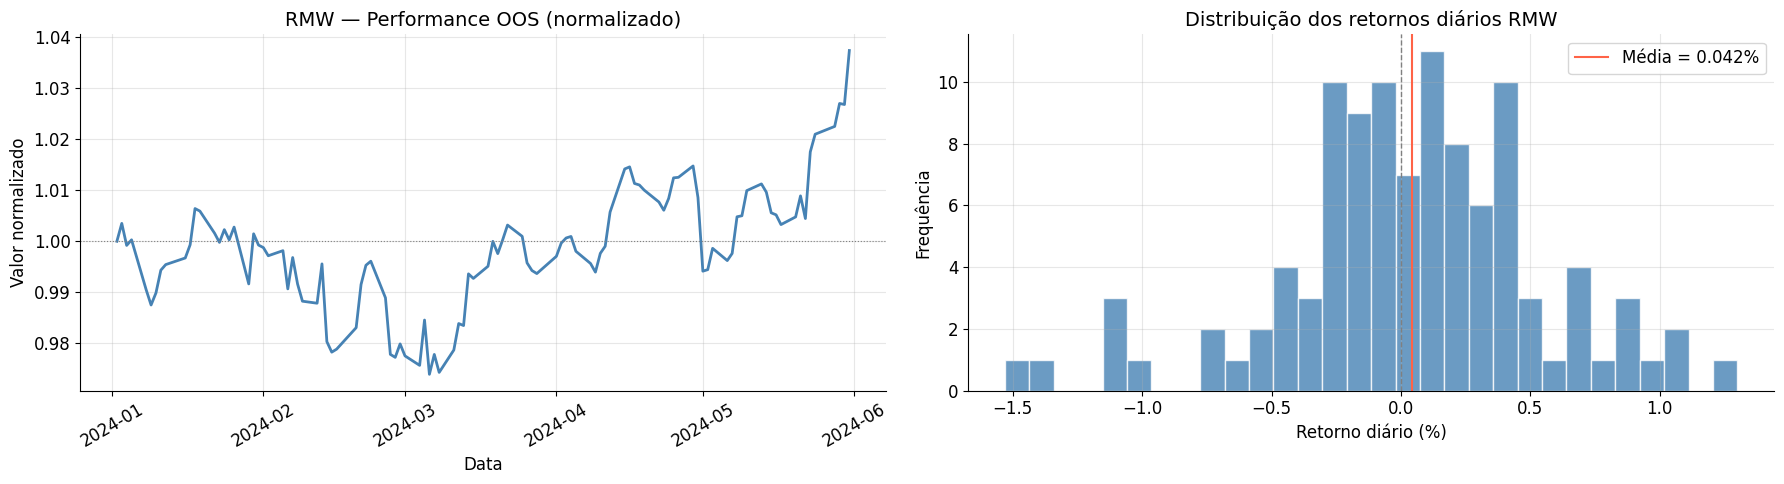

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/market_context_smb.pdf


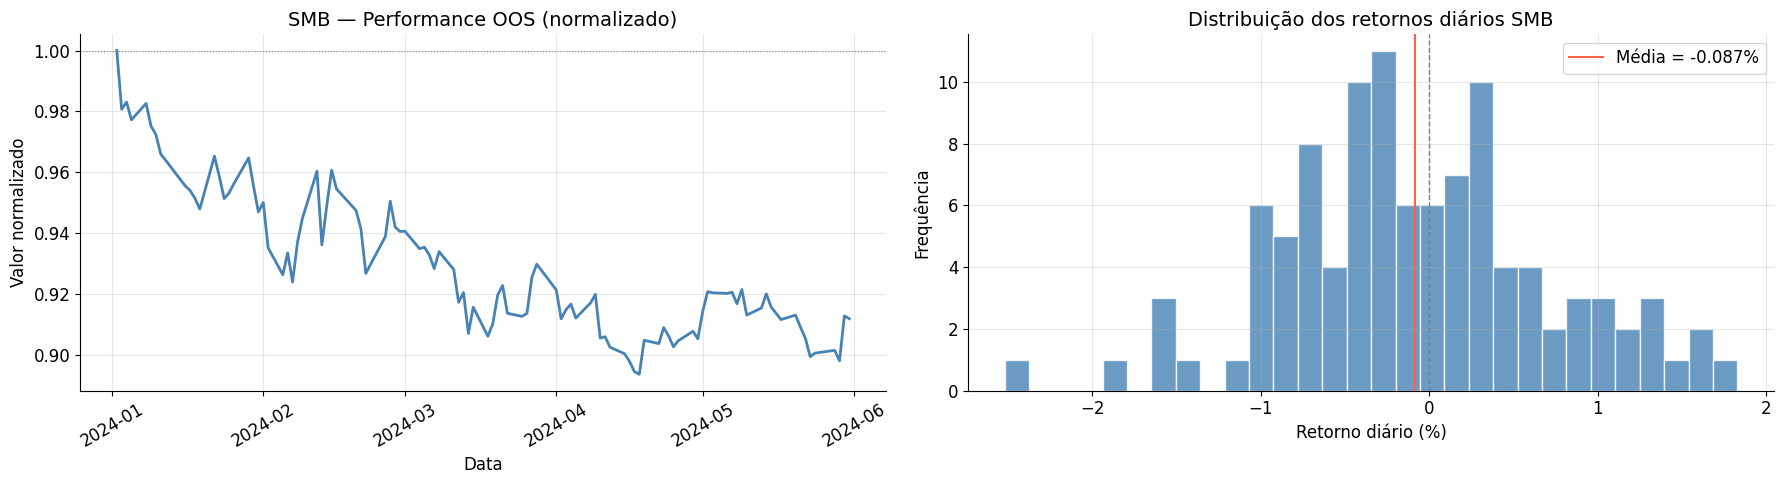

In [4]:
for bench, d in bench_data.items():
    plot_market_context(d['norm'], d['ret'], benchmark_name=bench,
                        save_path=TAFMSSD_DIR / f'market_context_{bench.lower()}.pdf')


---
## 4. Benchmark sintético OOS — análise detalhada

O benchmark sintético é `max_k(norm_k[t])` — o melhor benchmark normalizado em cada dia OOS.
Cada ponto absoluto in-sample é `max_k(sorted_b_k[s])` (salvo nos `synthetic_bench-*.csv`).

In [5]:
bench_ret_df   = pd.DataFrame({b: bench_data[b]['ret'] for b in AVAILABLE_BENCHMARKS}).reindex(idx)
dominant_bench = bench_ret_df.idxmax(axis=1)

print('Frequência de dominância (qual benchmark é o máximo em cada dia):')
for b, n in dominant_bench.value_counts().items():
    print(f'  {b:8s}  {n:3d} dias  ({n/len(idx)*100:.1f}%)')


Frequência de dominância (qual benchmark é o máximo em cada dia):
  RMW        26 dias  (24.8%)
  SMB        25 dias  (23.8%)
  SP500      19 dias  (18.1%)
  HML        14 dias  (13.3%)
  CMA        11 dias  (10.5%)
  MARKET     10 dias  (9.5%)


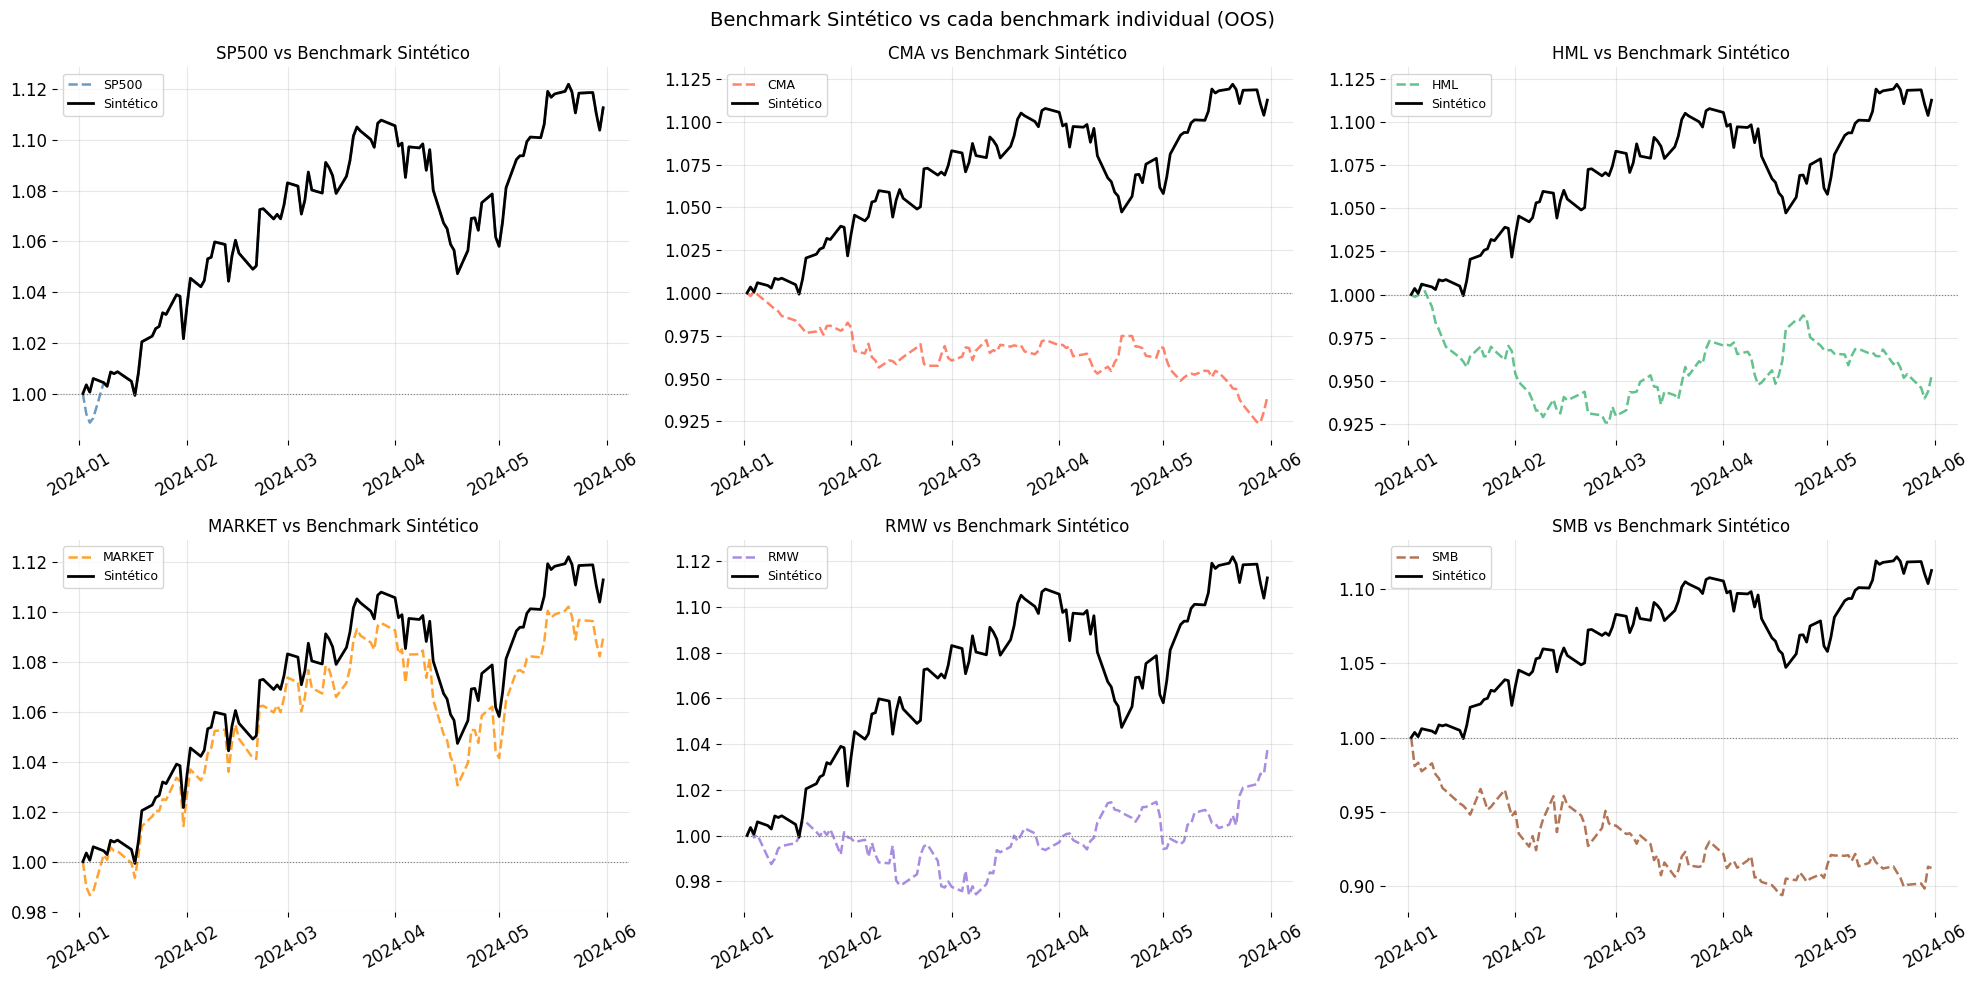

In [6]:
# Synthetic vs each benchmark
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.patch.set_facecolor('white')
palette = ['steelblue','tomato','mediumseagreen','darkorange','mediumpurple','sienna']

for i, (bench, d) in enumerate(bench_data.items()):
    ax = axes.flatten()[i]; ax.set_facecolor('white')
    ax.plot(d['norm'].index, d['norm'].values, color=palette[i],
            linewidth=1.8, linestyle='--', alpha=0.8, label=bench)
    ax.plot(synth_oos.index, synth_oos.values, color='black', linewidth=2.0, label='Sintético')
    ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(f'{bench} vs Benchmark Sintético', fontsize=12)
    ax.tick_params(axis='x', rotation=30)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.legend(fontsize=9)

plt.suptitle('Benchmark Sintético vs cada benchmark individual (OOS)', fontsize=14)
plt.tight_layout()
plt.savefig(TAFMSSD_DIR / 'synthetic_vs_individuals.pdf', bbox_inches='tight')
plt.show()


5 janelas encontradas



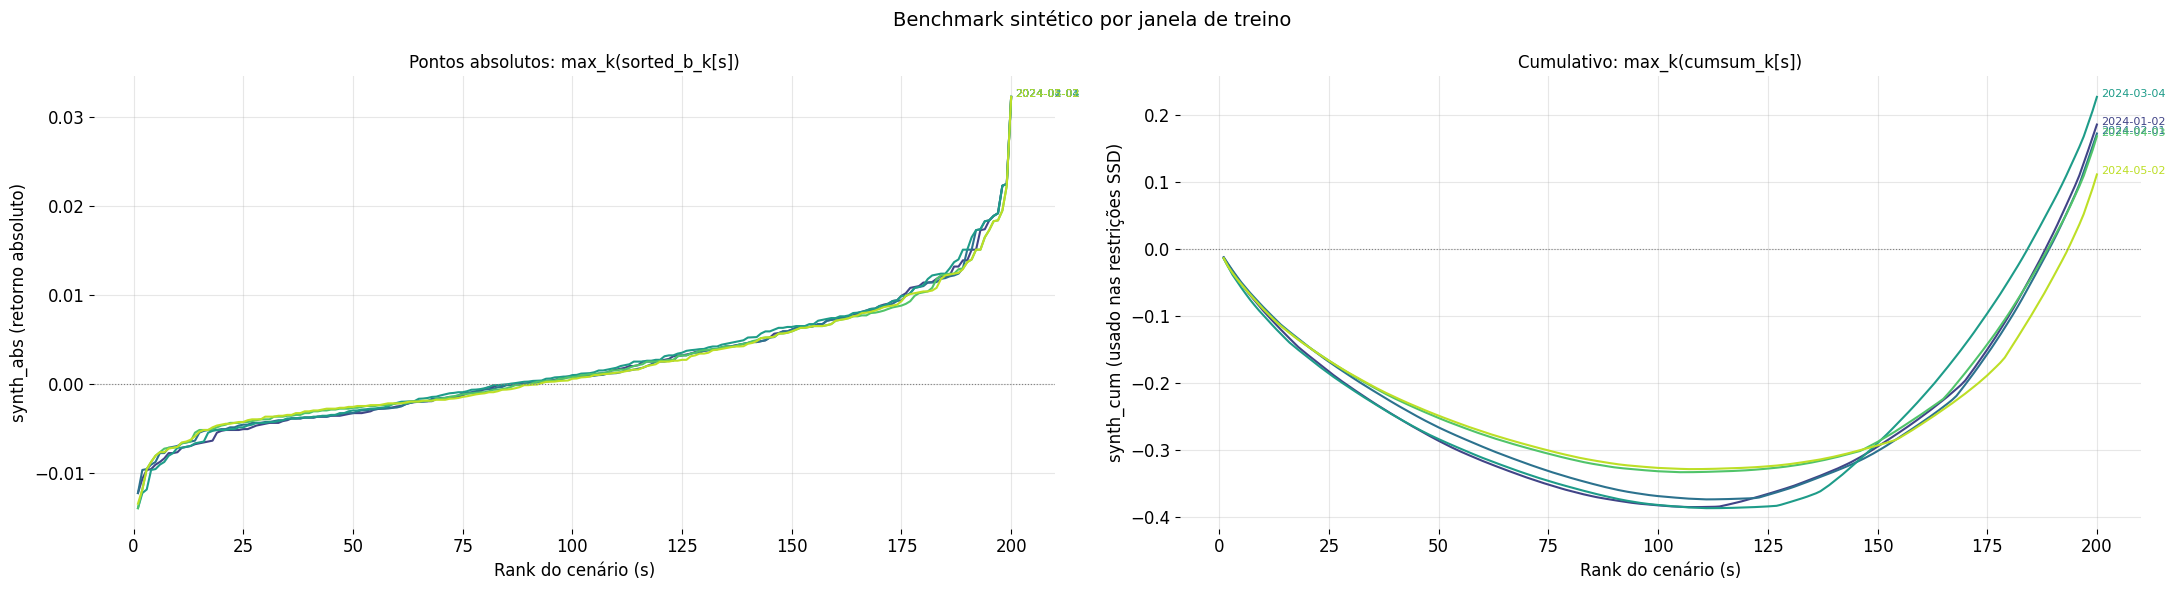

In [7]:
# Per-window synthetic benchmark curves (absolute points: synth_abs)
synth_files = sorted(TAFMSSD_DIR.glob('synthetic_bench-*.csv'))
print(f'{len(synth_files)} janelas encontradas\n')

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
fig.patch.set_facecolor('white')
colors_w = cm.viridis(np.linspace(0.2, 0.9, len(synth_files)))

for color, f in zip(colors_w, synth_files):
    df   = pd.read_csv(f)
    date = f.stem.replace('synthetic_bench-', '')
    axes[0].plot(df['rank'], df['synth_abs'], linewidth=1.5, color=color, label=date)
    axes[1].plot(df['rank'], df['synth_cum'], linewidth=1.5, color=color, label=date)
    axes[0].annotate(date, xy=(df['rank'].iloc[-1], df['synth_abs'].iloc[-1]),
                     xytext=(3,0), textcoords='offset points', fontsize=8, color=color)
    axes[1].annotate(date, xy=(df['rank'].iloc[-1], df['synth_cum'].iloc[-1]),
                     xytext=(3,0), textcoords='offset points', fontsize=8, color=color)

for ax, ttl, yl in zip(axes,
        ['Pontos absolutos: max_k(sorted_b_k[s])', 'Cumulativo: max_k(cumsum_k[s])'],
        ['synth_abs (retorno absoluto)', 'synth_cum (usado nas restrições SSD)']):
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(ttl, fontsize=12); ax.set_xlabel('Rank do cenário (s)')
    ax.set_ylabel(yl)
    for sp in ax.spines.values(): sp.set_visible(False)

plt.suptitle('Benchmark sintético por janela de treino', fontsize=14)
plt.tight_layout()
plt.savefig(TAFMSSD_DIR / 'synthetic_bench_windows.pdf', bbox_inches='tight')
plt.show()


---
## 4b. Por que tafmSSD pode superar scmSSD? — Análise de constraint tightness

### Equivalência teórica

Matematicamente, scmSSD e tafmSSD têm **exatamente o mesmo conjunto viável**.

- **scmSSD** exige dominância individual: `cumsum(sorted_port)[s] >= tau_k[s]`  ∀ k, s
- **tafmSSD** exige dominância sobre o envelope: `cumsum(sorted_port)[s] >= max_k(tau_k[s])`  ∀ s

Dominar o envelope implica dominar cada tau_k individualmente, e vice-versa.

### Onde a diferença surge na prática

A diferença não está na região viável, mas em **como o solver chega à solução**:

| | scmSSD | tafmSSD |
|--|--------|---------|
| Variáveis Vs | K × S | S |
| Cortes lazy | mais violado dentre K×S combinações | mais violado dentre S (contra envelope) |
| Graus de liberdade | maior — solver pode "trocar" entre K benchmarks | menor — restrição é sempre o pior caso |

Em scmSSD, os K conjuntos de variáveis `Vs_{k,t}` oferecem ao solver mais espaço de manobra
durante o branch-and-bound. O otimizador pode encontrar soluções que dominam com folga um
benchmark fraco enquanto raspa o limite em outro — produzindo pesos especializados no regime
de treino. Em tafmSSD, a restrição é sempre contra o **harder benchmark em cada rank**,
forçando pesos que são robustos a mudanças de qual benchmark é mais exigente no OOS.

### O que esperar dos gráficos abaixo

- `tau_synth[s]` (preto) é sempre ≥ todos os `tau_k[s]` por construção
- A **distância entre o envelope e cada curva individual** mostra quanto o portfólio precisa
  acumular A MAIS do que aquele benchmark exigiria sozinho
- A **alternância de qual benchmark é dominante** entre ranks indica quantos regimes distintos
  estão embutidos na restrição sintética — quanto mais alternância, mais "composta" a restrição
  e mais diversificado o portfólio resultante


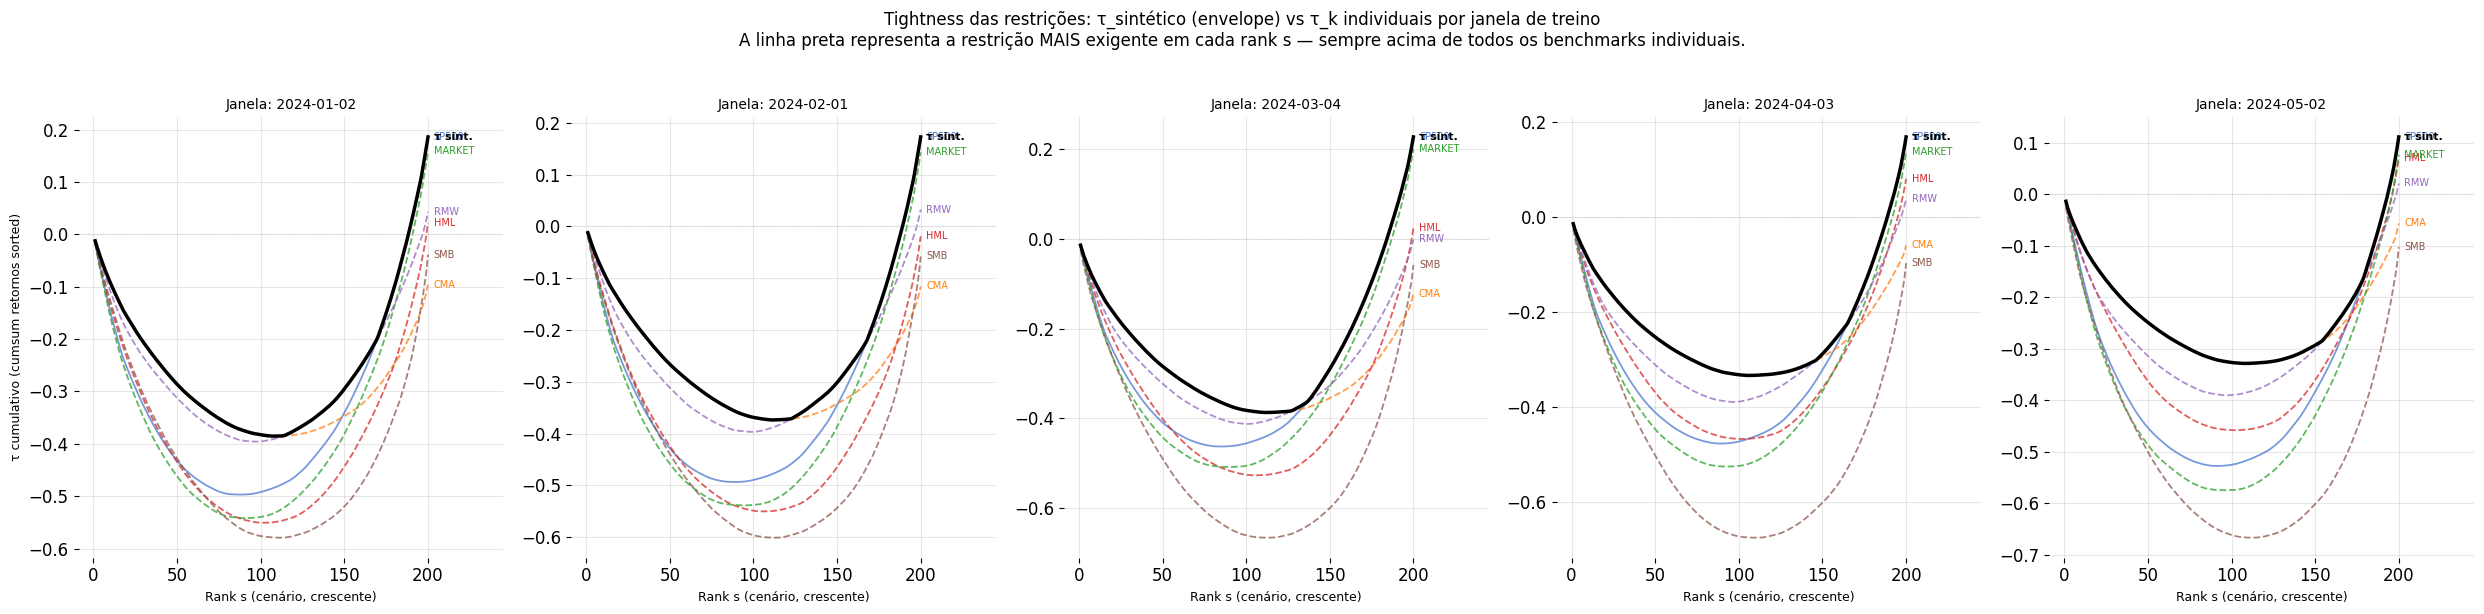

In [8]:
# ── Reconstruct tau_k per benchmark per training window ───────────────────────
TRAIN_DAYS = 200
bench_full = market_returns[AVAILABLE_BENCHMARKS]

PALETTE = {
    'SP500':  ('#4878cf', '-'),
    'CMA':    ('#ff7f0e', '--'),
    'HML':    ('#d62728', '--'),
    'MARKET': ('#2ca02c', '--'),
    'RMW':    ('#9467bd', '--'),
    'SMB':    ('#8c564b', '--'),
}

synth_files = sorted(TAFMSSD_DIR.glob('synthetic_bench-*.csv'))
n_windows   = len(synth_files)

fig, axes = plt.subplots(1, n_windows, figsize=(5 * n_windows, 6), sharey=False)
fig.patch.set_facecolor('white')

tau_by_window = {}

for ax, f in zip(axes, synth_files):
    date_str = f.stem.replace('synthetic_bench-', '')
    date     = pd.Timestamp(date_str)
    ax.set_facecolor('white')

    loc     = bench_full.index.get_loc(date)
    train_b = bench_full.iloc[max(0, loc - TRAIN_DAYS + 1): loc + 1]
    S       = len(train_b)
    ranks   = np.arange(1, S + 1)

    tau_matrix = {}
    for b in AVAILABLE_BENCHMARKS:
        tau_matrix[b] = np.cumsum(np.sort(train_b[b].values))

    tau_by_window[date_str] = tau_matrix

    synth_df = pd.read_csv(f)

    for b, (color, ls) in PALETTE.items():
        ax.plot(ranks, tau_matrix[b], linewidth=1.3, linestyle=ls,
                color=color, alpha=0.75, label=b)

    for b, (color, _) in PALETTE.items():
        ax.annotate(b, xy=(ranks[-1], tau_matrix[b][-1]),
                    xytext=(4, 0), textcoords='offset points',
                    va='center', fontsize=7, color=color)

    ax.plot(synth_df['rank'], synth_df['synth_cum'],
            linewidth=2.5, color='black', zorder=5, label='τ sintético')
    ax.annotate('τ sint.', xy=(synth_df['rank'].iloc[-1], synth_df['synth_cum'].iloc[-1]),
                xytext=(4, 0), textcoords='offset points',
                va='center', fontsize=8, color='black', fontweight='bold')

    ax.axhline(0, color='lightgray', linewidth=0.8, linestyle=':')
    x_min, x_max = ax.get_xlim()
    ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.16)
    ax.set_title(f'Janela: {date_str}', fontsize=10)
    ax.set_xlabel('Rank s (cenário, crescente)', fontsize=9)
    for sp in ax.spines.values(): sp.set_visible(False)

axes[0].set_ylabel('τ cumulativo (cumsum retornos sorted)', fontsize=9)

fig.suptitle(
    'Tightness das restrições: τ_sintético (envelope) vs τ_k individuais por janela de treino\n'
    'A linha preta representa a restrição MAIS exigente em cada rank s — '
    'sempre acima de todos os benchmarks individuais.',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig(TAFMSSD_DIR / 'constraint_tightness.pdf', bbox_inches='tight')
plt.show()


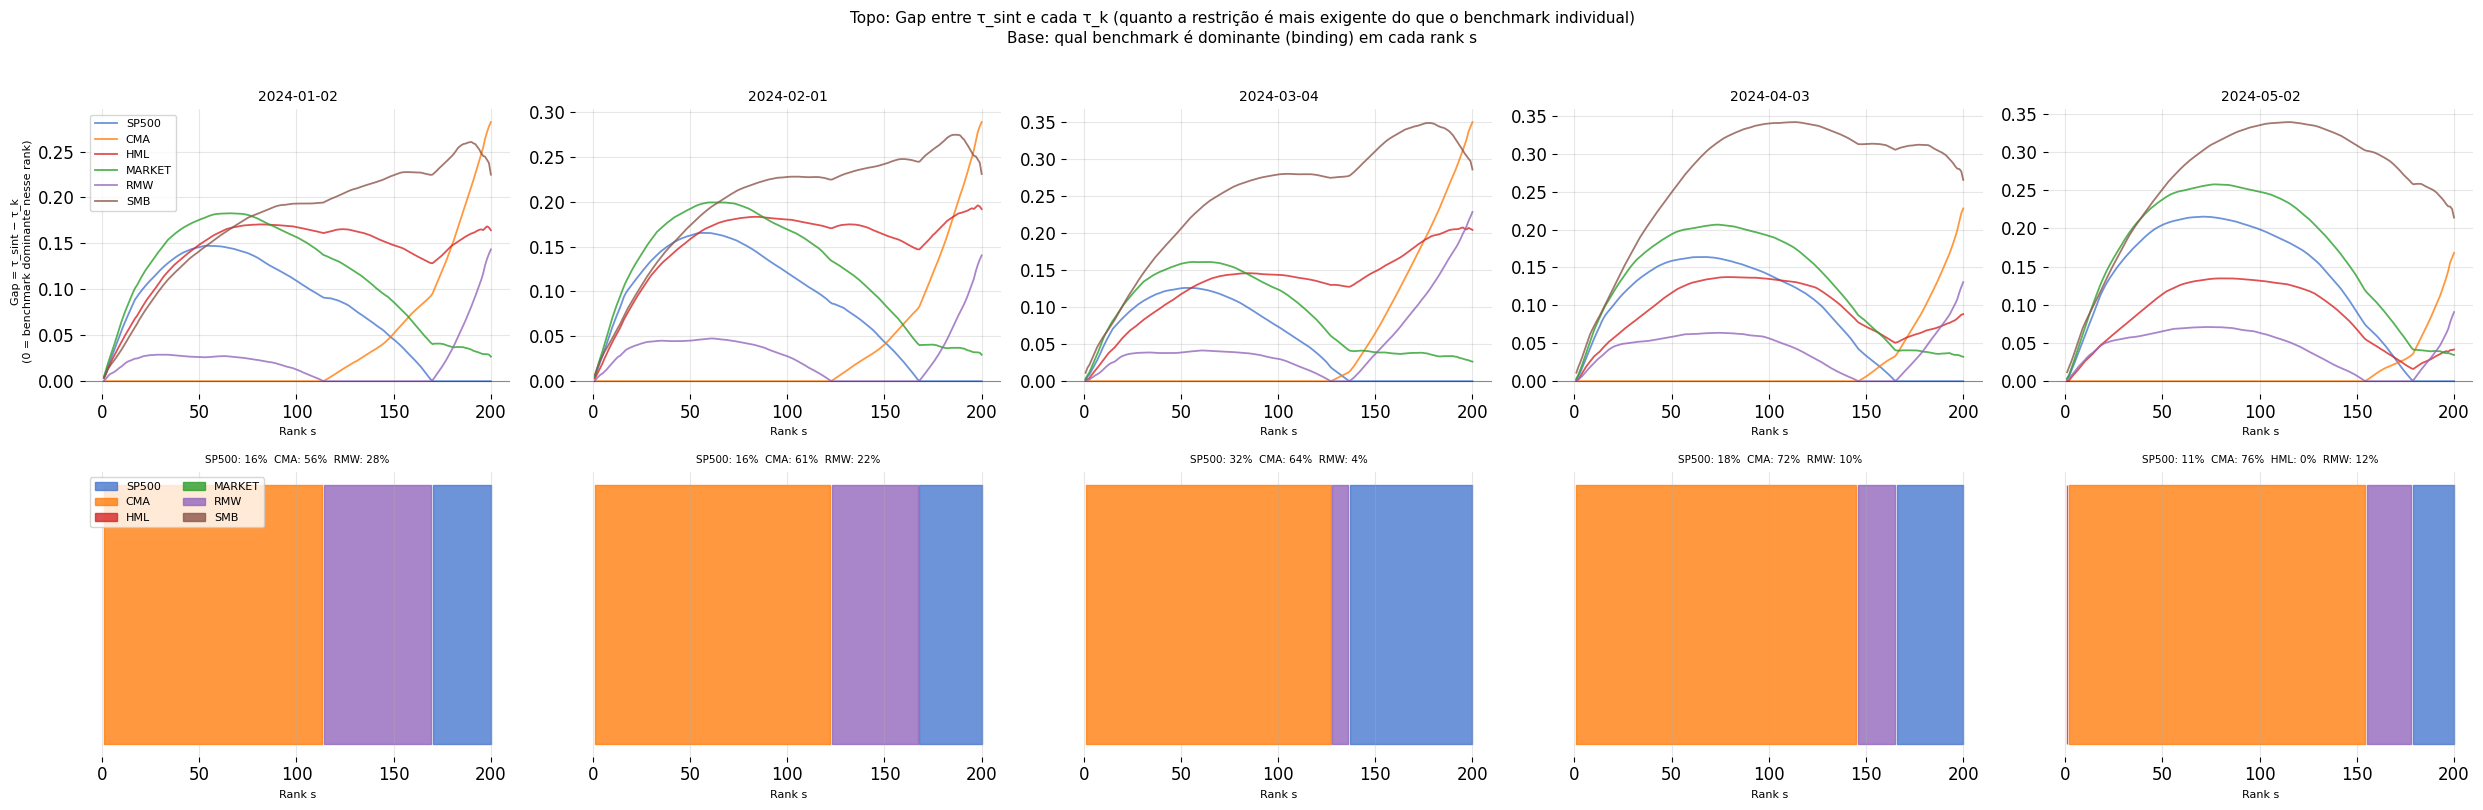

In [9]:
# ── Dominant benchmark at each rank s, per training window ────────────────────
BENCH_ORDER  = AVAILABLE_BENCHMARKS
BENCH_COLORS = [PALETTE[b][0] for b in BENCH_ORDER]

fig, axes = plt.subplots(2, n_windows, figsize=(5 * n_windows, 8))
fig.patch.set_facecolor('white')

for col_i, (f, date_str) in enumerate(
        [(f, f.stem.replace('synthetic_bench-', '')) for f in synth_files]):

    tau_matrix = tau_by_window[date_str]
    stacked    = np.column_stack([tau_matrix[b] for b in BENCH_ORDER])
    dom_idx    = np.argmax(stacked, axis=1)
    S          = stacked.shape[0]
    ranks      = np.arange(1, S + 1)

    ax_top = axes[0, col_i]
    ax_top.set_facecolor('white')
    synth_vec = stacked[np.arange(S), dom_idx]

    for i, (b, color) in enumerate(zip(BENCH_ORDER, BENCH_COLORS)):
        gap = synth_vec - stacked[:, i]
        ax_top.plot(ranks, gap, linewidth=1.3, color=color, alpha=0.8, label=b)

    ax_top.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
    ax_top.set_title(f'{date_str}', fontsize=10)
    ax_top.set_xlabel('Rank s', fontsize=8)
    if col_i == 0:
        ax_top.set_ylabel('Gap = τ_sint − τ_k\n(0 = benchmark dominante nesse rank)', fontsize=8)
    for sp in ax_top.spines.values(): sp.set_visible(False)

    ax_bot = axes[1, col_i]
    ax_bot.set_facecolor('white')

    for i, (b, color) in enumerate(zip(BENCH_ORDER, BENCH_COLORS)):
        mask = (dom_idx == i)
        ax_bot.fill_between(ranks, 0, 1, where=mask,
                            color=color, alpha=0.8, label=b if col_i == 0 else None)

    from collections import Counter
    cnt = Counter(int(j) for j in dom_idx)
    summary = '  '.join(f'{BENCH_ORDER[k]}: {cnt[k]/S*100:.0f}%'
                        for k in sorted(cnt) if cnt[k] > 0)
    ax_bot.set_title(summary, fontsize=7.5)
    ax_bot.set_xlabel('Rank s', fontsize=8)
    ax_bot.set_yticks([])
    for sp in ax_bot.spines.values(): sp.set_visible(False)

axes[0, 0].legend(fontsize=8, loc='upper left')
axes[1, 0].legend(fontsize=8, loc='upper left', ncol=2)

fig.suptitle(
    'Topo: Gap entre τ_sint e cada τ_k (quanto a restrição é mais exigente do que o benchmark individual)\n'
    'Base: qual benchmark é dominante (binding) em cada rank s',
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(TAFMSSD_DIR / 'constraint_dominance_by_rank.pdf', bbox_inches='tight')
plt.show()


In [10]:
# ── Summary: constraint tightening magnitude ──────────────────────────────────
# For each window, compute the average extra tightening imposed by tafmSSD vs
# each individual benchmark: mean_s(tau_synth[s] - tau_k[s])

print('Tightening médio imposto pelo benchmark sintético vs cada benchmark individual')
print('(quanto a mais o portfólio precisa acumular em média vs usar cada benchmark sozinho)')
print()
print(f'{"Benchmark":<10} ' + '  '.join(f'{f.stem[-10:]:>12}' for f in synth_files))
print('-' * (10 + 14 * n_windows))

for b in BENCH_ORDER:
    row = f'{b:<10} '
    for date_str in [f.stem.replace("synthetic_bench-", "") for f in synth_files]:
        tau_mat = tau_by_window[date_str]
        synth   = np.max(np.column_stack(list(tau_mat.values())), axis=1)
        gap     = synth - tau_mat[b]
        row    += f'  {gap.mean():+12.6f}'
    print(row)

print()
print('Observação: gap = 0 quando o benchmark é dominante em TODOS os ranks (não acontece na prática).')
print('Gap > 0 indica que o tafmSSD exige que o portfólio supere esse benchmark por uma margem adicional.')


Tightening médio imposto pelo benchmark sintético vs cada benchmark individual
(quanto a mais o portfólio precisa acumular em média vs usar cada benchmark sozinho)

Benchmark    2024-01-02    2024-02-01    2024-03-04    2024-04-03    2024-05-02
--------------------------------------------------------------------------------
SP500           +0.080663     +0.087924     +0.055146     +0.090430     +0.130072
CMA             +0.039864     +0.037538     +0.052272     +0.022376     +0.012755
HML             +0.140854     +0.153690     +0.131542     +0.094582     +0.084302
MARKET          +0.115466     +0.123671     +0.090440     +0.128278     +0.167898
RMW             +0.021541     +0.030464     +0.050562     +0.042249     +0.042293
SMB             +0.175140     +0.199425     +0.246756     +0.272816     +0.263215

Observação: gap = 0 quando o benchmark é dominante em TODOS os ranks (não acontece na prática).
Gap > 0 indica que o tafmSSD exige que o portfólio supere esse benchmark por uma marg

---
## 5. Visão geral — todos os modelos

Comparação normalizada de todos os portfólios da família SSD (scSSD, scmSSD por fator, tafmSSD) com os benchmarks.

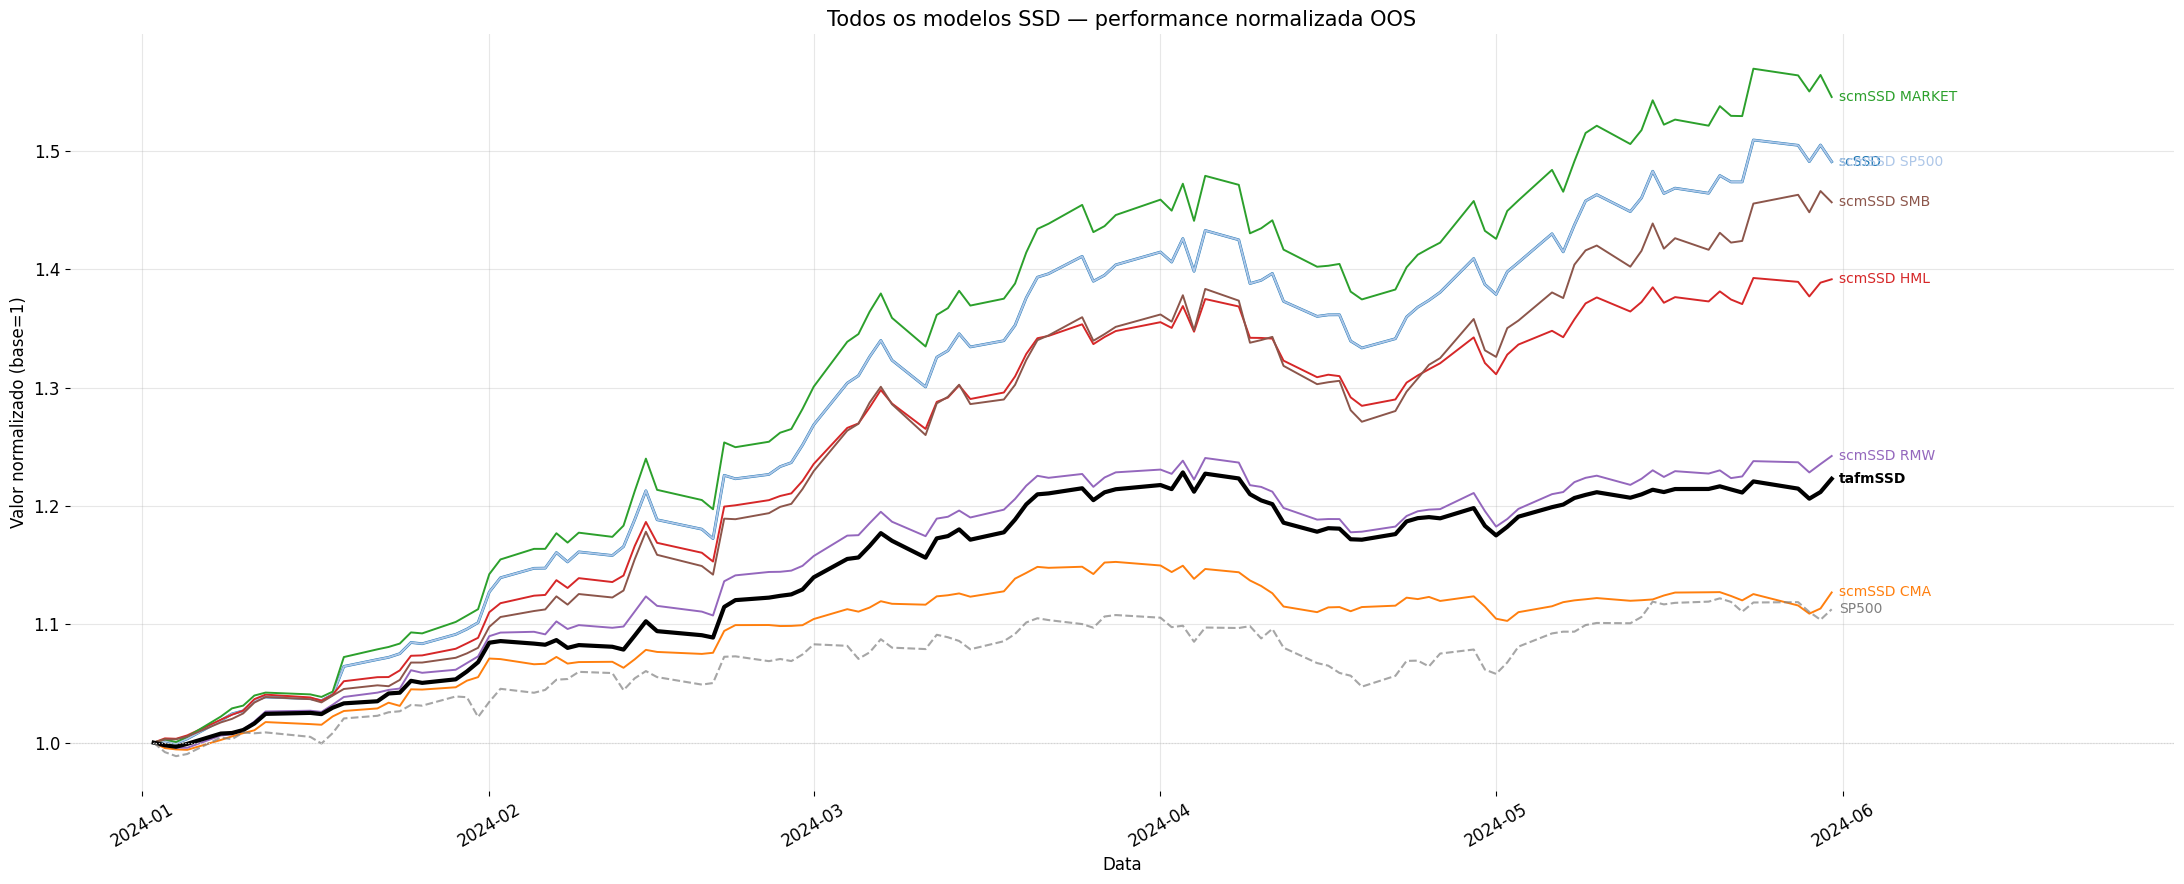

In [11]:
# Define visual groups
GROUP_COLORS = {
    'scSSD':         '#1f77b4',
    'scmSSD SP500':  '#aec7e8',
    'scmSSD CMA':    '#ff7f0e',
    'scmSSD HML':    '#d62728',
    'scmSSD MARKET': '#2ca02c',
    'scmSSD RMW':    '#9467bd',
    'scmSSD SMB':    '#8c564b',
    'tafmSSD':       '#000000',
}

fig, ax = plt.subplots(figsize=(22, 9))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for label, series in models.items():
    color = GROUP_COLORS.get(label, '#999999')
    lw    = 3.0 if label == 'tafmSSD' else (2.0 if label == 'scSSD' else 1.4)
    ax.plot(idx, series.values, linewidth=lw, color=color, linestyle='-')
    ax.annotate(label, xy=(idx[-1], series.iloc[-1]),
                xytext=(5, 0), textcoords='offset points', va='center',
                fontsize=10, color=color,
                fontweight='bold' if label == 'tafmSSD' else 'normal')

ax.plot(idx, sp500_norm.values, linewidth=1.5, color='gray', linestyle='--', alpha=0.7)
ax.annotate('SP500', xy=(idx[-1], sp500_norm.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center',
            fontsize=10, color='gray')

ax.axhline(1.0, color='lightgray', linewidth=0.8, linestyle=':')
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.14)
ax.set_title('Todos os modelos SSD — performance normalizada OOS', fontsize=15)
ax.set_xlabel('Data'); ax.set_ylabel('Valor normalizado (base=1)')
ax.tick_params(axis='x', rotation=30)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(TAFMSSD_DIR / 'all_models_comparison.pdf', bbox_inches='tight')
plt.show()


---
## 6. scmSSD por fator vs tafmSSD

Comparação direta entre os portfólios otimizados contra fatores Fama-French individuais e o tafmSSD (que usa o benchmark sintético — máximo dos K fatores).

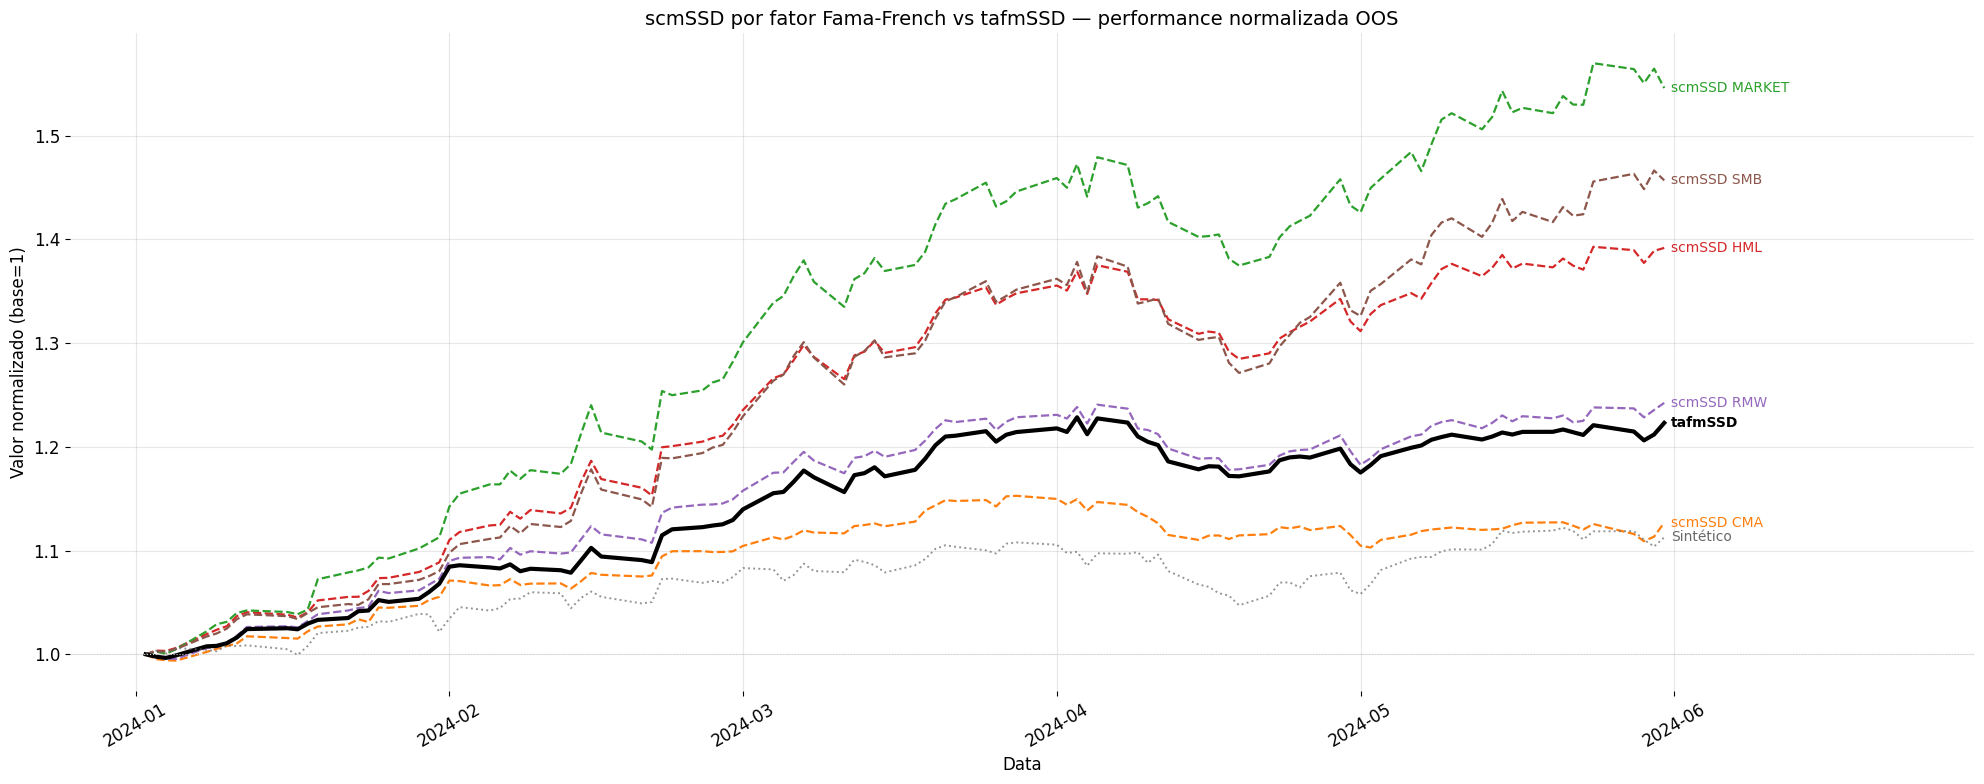

In [12]:
factor_models = {k: v for k, v in models.items()
                 if k.startswith('scmSSD') and k != 'scmSSD SP500'}
factor_models['tafmSSD'] = models['tafmSSD']

fig, ax = plt.subplots(figsize=(20, 8))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

colors_f = ['#ff7f0e','#d62728','#2ca02c','#9467bd','#8c564b']
line_labels = []

for i, (label, series) in enumerate(factor_models.items()):
    if label == 'tafmSSD':
        color, lw, ls = 'black', 3.0, '-'
    else:
        color = colors_f[i % len(colors_f)]
        lw, ls = 1.6, '--'
    ax.plot(idx, series.values, linewidth=lw, linestyle=ls, color=color)
    line_labels.append((idx[-1], series.iloc[-1], label, color))

ax.plot(synth_oos.index, synth_oos.values, linewidth=1.4, linestyle=':', color='dimgray', alpha=0.7)
line_labels.append((synth_oos.index[-1], synth_oos.iloc[-1], 'Sintético', 'dimgray'))

ax.axhline(1.0, color='lightgray', linewidth=0.8, linestyle=':')
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.14)

for xp, yp, lbl, col in line_labels:
    ax.annotate(lbl, xy=(xp, yp), xytext=(5, 0), textcoords='offset points',
                va='center', fontsize=10, color=col,
                fontweight='bold' if lbl == 'tafmSSD' else 'normal')

ax.set_title('scmSSD por fator Fama-French vs tafmSSD — performance normalizada OOS', fontsize=14)
ax.set_xlabel('Data'); ax.set_ylabel('Valor normalizado (base=1)')
ax.tick_params(axis='x', rotation=30)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(TAFMSSD_DIR / 'factor_models_vs_tafmssd.pdf', bbox_inches='tight')
plt.show()


[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/factor_vs_taf_comparison.pdf


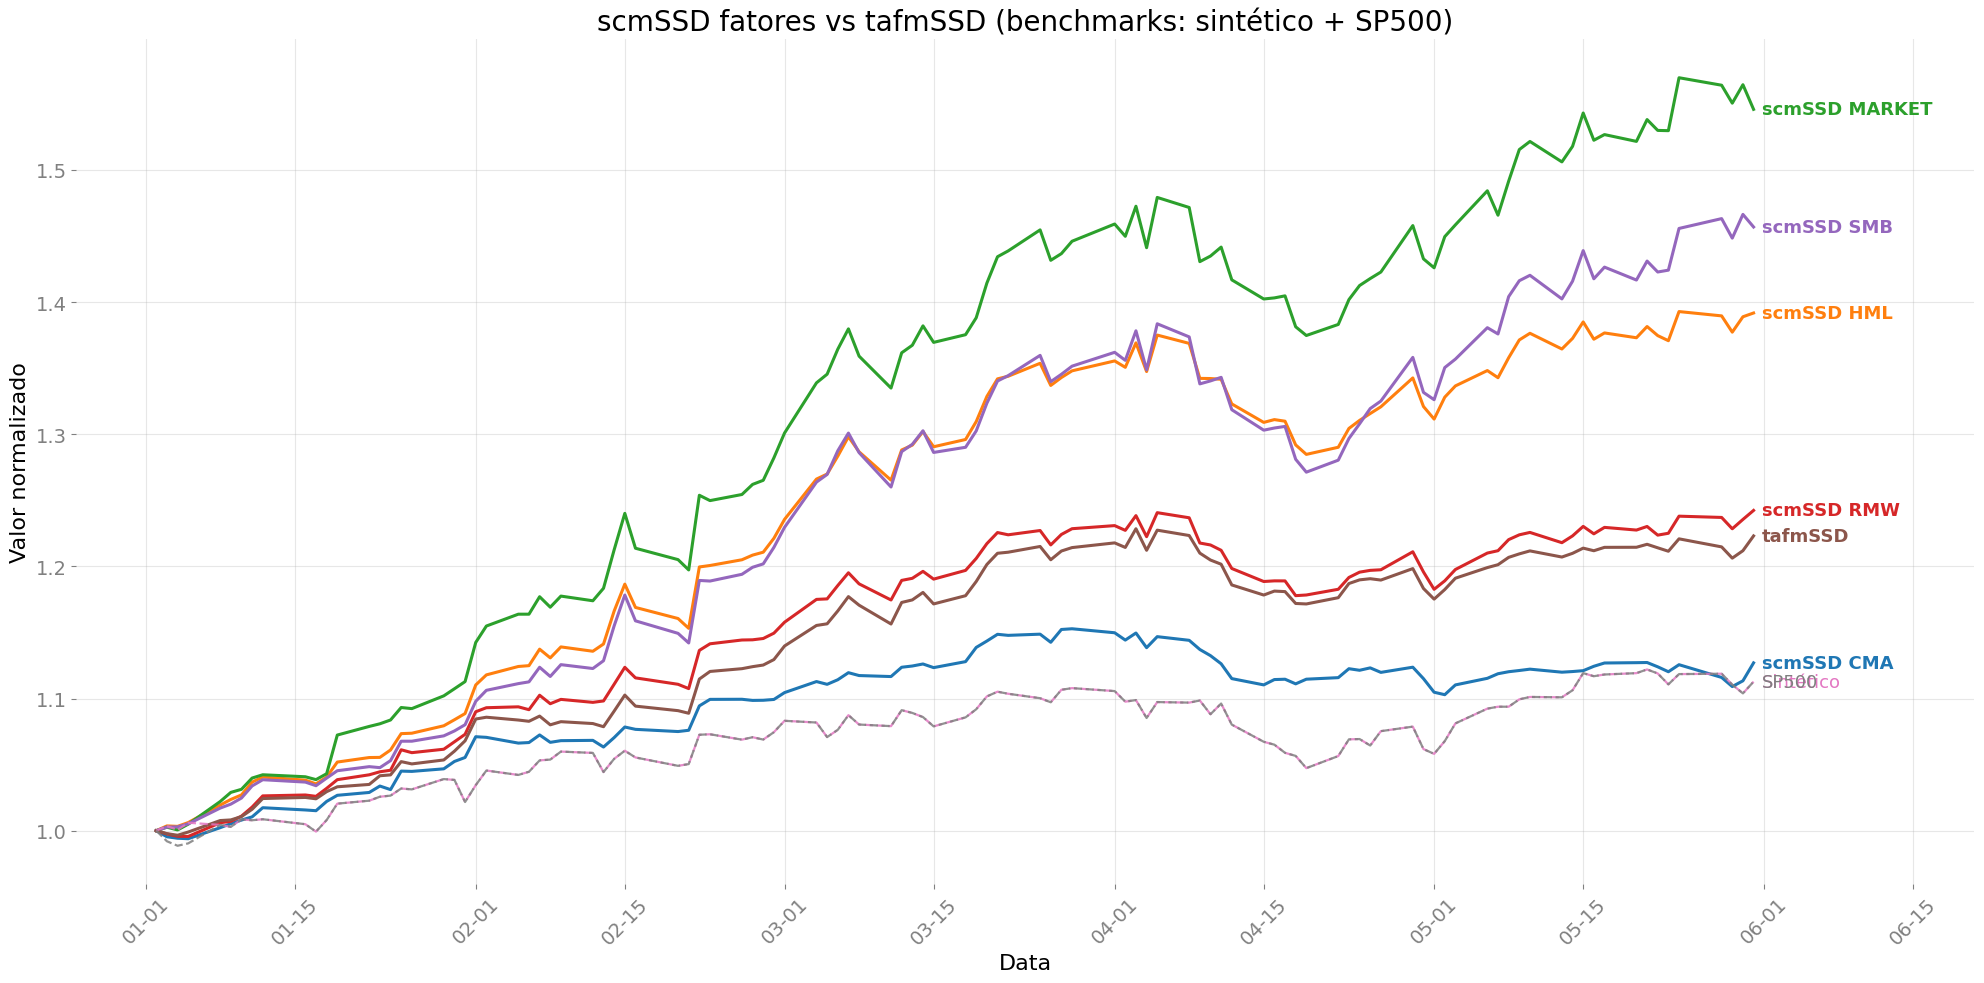

In [13]:
# Benchmark sintético como referência
combined_f = pd.DataFrame(index=idx)
for label, series in factor_models.items():
    combined_f[label] = series
combined_f['Sintético'] = synth_oos
combined_f['SP500']     = sp500_norm

benchmark_cols = ['Sintético', 'SP500']
plot_portfolio_comparison(
    combined_f,
    force_background=True,
    benchmark_cols=benchmark_cols,
    title='scmSSD fatores vs tafmSSD (benchmarks: sintético + SP500)',
    save_path=TAFMSSD_DIR / 'factor_vs_taf_comparison.pdf',
)


---
## 7. Drawdown comparativo — todos os modelos

Análise de drawdown para scSSD, scmSSD (por fator), tafmSSD e SP500.

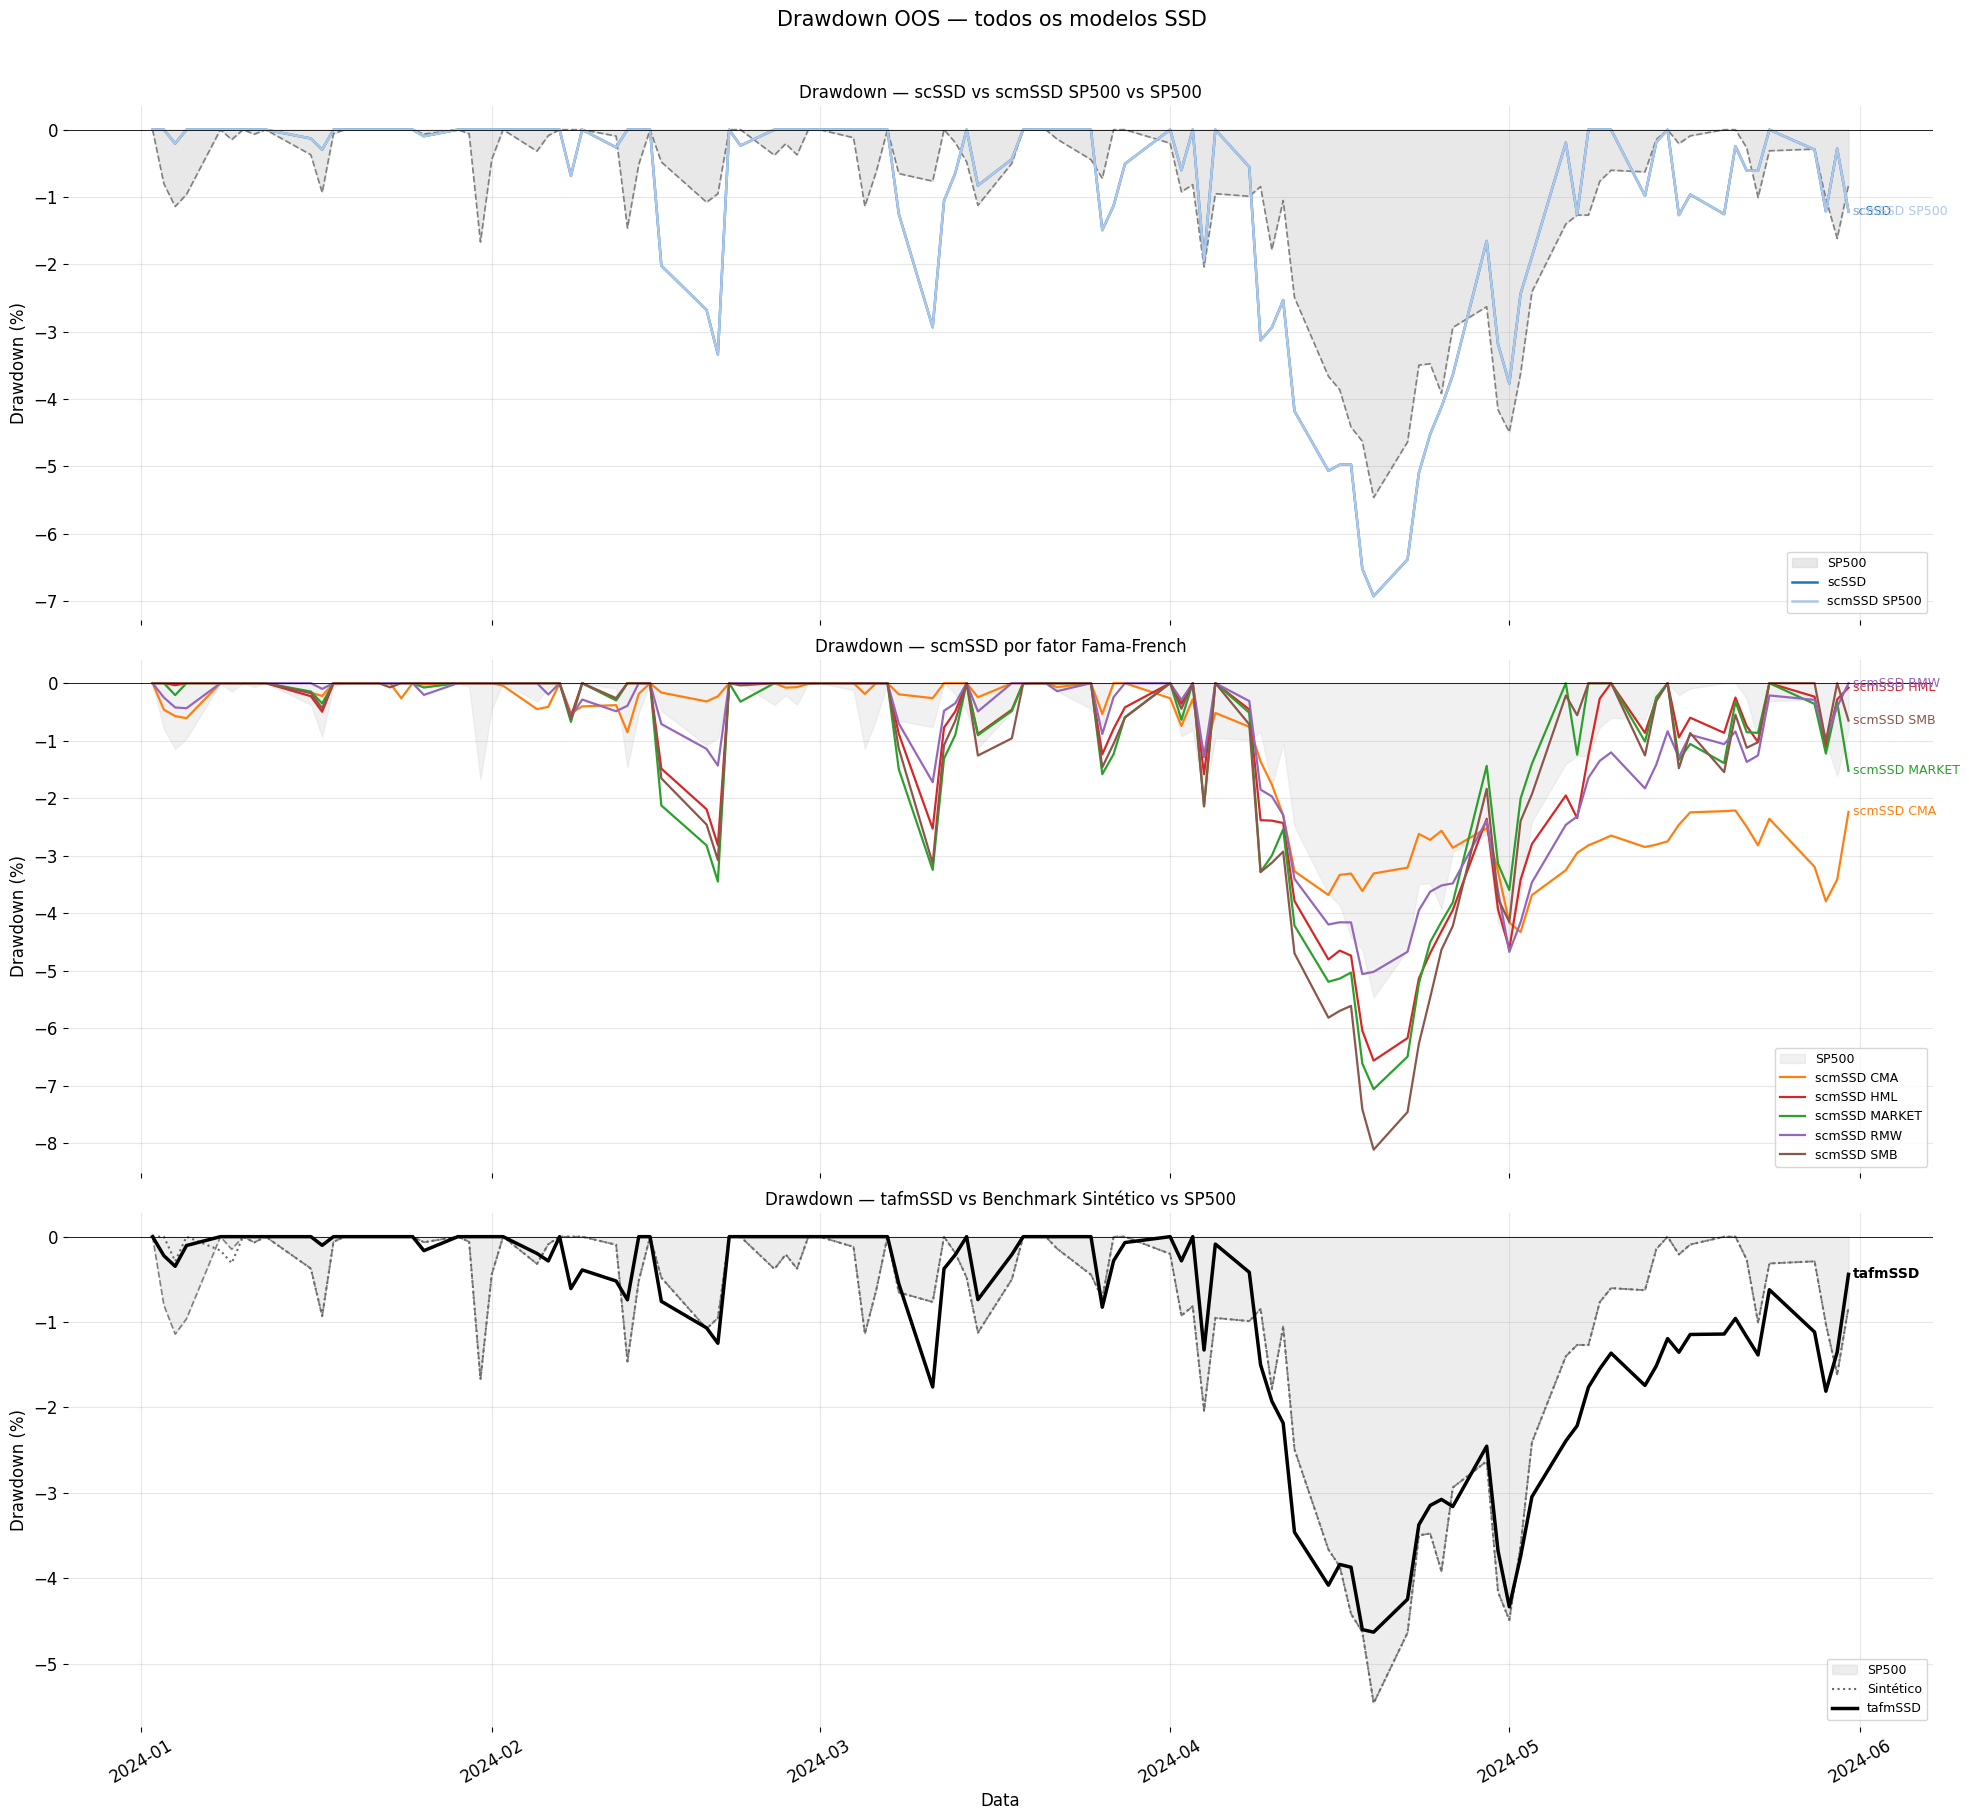

In [14]:
# Grouped drawdown: all models + SP500 + synthetic
def compute_drawdown(series):
    roll_max = series.expanding().max()
    return (series / roll_max - 1) * 100

fig, axes = plt.subplots(3, 1, figsize=(20, 18), sharex=True)
fig.patch.set_facecolor('white')

# Panel 1: scSSD vs scmSSD SP500 vs SP500
ax1 = axes[0]; ax1.set_facecolor('white')
sp500_dd = compute_drawdown(sp500_norm)
ax1.fill_between(idx, sp500_dd.values, 0, color='lightgray', alpha=0.5, label='SP500')
ax1.plot(idx, sp500_dd.values, color='gray', linewidth=1.2, linestyle='--')

for label in ['scSSD', 'scmSSD SP500']:
    if label in models:
        dd    = compute_drawdown(models[label])
        color = GROUP_COLORS.get(label, 'blue')
        ax1.plot(idx, dd.values, linewidth=1.8, color=color, label=label)
        ax1.annotate(label, xy=(idx[-1], dd.iloc[-1]), xytext=(3,0),
                     textcoords='offset points', va='center', fontsize=9, color=color)

ax1.axhline(0, color='black', linewidth=0.6)
ax1.set_title('Drawdown — scSSD vs scmSSD SP500 vs SP500', fontsize=12)
ax1.set_ylabel('Drawdown (%)')
ax1.legend(fontsize=9, loc='lower right')
for sp in ax1.spines.values(): sp.set_visible(False)

# Panel 2: scmSSD por fator
ax2 = axes[1]; ax2.set_facecolor('white')
ax2.fill_between(idx, sp500_dd.values, 0, color='lightgray', alpha=0.3, label='SP500')

for i, b in enumerate(FACTOR_BENCHMARKS):
    label = f'scmSSD {b}'
    if label in models:
        dd    = compute_drawdown(models[label])
        color = colors_f[i]
        ax2.plot(idx, dd.values, linewidth=1.6, color=color, label=label)
        ax2.annotate(label, xy=(idx[-1], dd.iloc[-1]), xytext=(3,0),
                     textcoords='offset points', va='center', fontsize=9, color=color)

ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_title('Drawdown — scmSSD por fator Fama-French', fontsize=12)
ax2.set_ylabel('Drawdown (%)')
ax2.legend(fontsize=9, loc='lower right')
for sp in ax2.spines.values(): sp.set_visible(False)

# Panel 3: tafmSSD vs sintético vs SP500
ax3 = axes[2]; ax3.set_facecolor('white')
ax3.fill_between(idx, sp500_dd.values, 0, color='lightgray', alpha=0.4, label='SP500')
ax3.plot(idx, sp500_dd.values, color='gray', linewidth=1.2, linestyle='--')

synth_dd = compute_drawdown(synth_oos)
ax3.plot(idx, synth_dd.values, linewidth=1.5, linestyle=':', color='dimgray', label='Sintético')

if 'tafmSSD' in models:
    taf_dd = compute_drawdown(models['tafmSSD'])
    ax3.plot(idx, taf_dd.values, linewidth=2.5, color='black', label='tafmSSD')
    ax3.annotate('tafmSSD', xy=(idx[-1], taf_dd.iloc[-1]), xytext=(3,0),
                 textcoords='offset points', va='center', fontsize=10, color='black',
                 fontweight='bold')

ax3.axhline(0, color='black', linewidth=0.6)
ax3.set_title('Drawdown — tafmSSD vs Benchmark Sintético vs SP500', fontsize=12)
ax3.set_ylabel('Drawdown (%)'); ax3.set_xlabel('Data')
ax3.legend(fontsize=9, loc='lower right')
ax3.tick_params(axis='x', rotation=30)
for sp in ax3.spines.values(): sp.set_visible(False)

plt.suptitle('Drawdown OOS — todos os modelos SSD', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(TAFMSSD_DIR / 'drawdown_all_models.pdf', bbox_inches='tight')
plt.show()


---
## 8. Métricas OOS — tabela completa

Todas as métricas para todos os modelos, com SP500 como benchmark de referência.

In [15]:
rows = {}
rows['SP500']     = compute_metrics(sp500_norm, benchmark=sp500_norm, rf_annual=RISK_FREE)
rows['Sintético'] = compute_metrics(synth_oos,  benchmark=sp500_norm, rf_annual=RISK_FREE)

# scSSD + scmSSD + tafmSSD
for label in ['scSSD', 'scmSSD SP500'] + [f'scmSSD {b}' for b in FACTOR_BENCHMARKS] + ['tafmSSD']:
    if label in models:
        rows[label] = compute_metrics(models[label], benchmark=sp500_norm, rf_annual=RISK_FREE)

metrics_df = pd.DataFrame(rows).T
display(
    metrics_df.style
    .background_gradient(cmap='RdYlGn',
        subset=['Final value', 'CAGR (%)', 'Sharpe Ratio', 'Sortino Ratio'])
    .background_gradient(cmap='RdYlGn_r',
        subset=['Volatility (%)', 'Daily CVaR 5% (%)', 'Max Drawdown (%)'])
    .format(precision=4, na_rep='--')
)


,Final value,CAGR (%),Volatility (%),Daily CVaR 5% (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Portfolio beta
SP500,1.1127,29.5400,11.3400,1.4070,1.9096,3.5279,-5.4600,1.0000
Sintético,1.1127,29.5400,11.0900,1.4070,1.9500,3.5197,-5.4600,0.9409
scSSD,1.4911,163.2900,18.2900,1.9300,5.1260,15.2550,-6.9300,1.0043
scmSSD SP500,1.4911,163.2900,18.2900,1.9300,5.1260,15.2550,-6.9300,1.0043
scmSSD CMA,1.1270,33.5900,7.9300,0.8550,3.0776,6.6670,-4.3300,0.4519
scmSSD HML,1.3917,122.7500,15.3300,1.6120,4.9903,13.6981,-6.5700,0.8740
scmSSD MARKET,1.5458,187.2900,19.8100,2.0450,5.1909,16.2442,-7.0600,1.0749
scmSSD RMW,1.2423,69.1700,11.0000,1.2260,4.3970,9.7383,-5.0600,0.6417
scmSSD SMB,1.4568,148.8400,18.4200,2.0720,4.7853,13.1262,-8.1100,0.9653
tafmSSD,1.2230,62.8800,10.2900,1.1700,4.3224,9.3841,-4.6300,0.6071


---
## 9. Dominância SSD — cada modelo vs seu benchmark de otimização

In [16]:
# For each model, verify it dominates its own optimization benchmark
HOME_BENCH = {
    'scSSD':         bench_data['SP500']['ret'],
    'scmSSD SP500':  bench_data['SP500']['ret'],
    'scmSSD CMA':    bench_data['CMA']['ret'],
    'scmSSD HML':    bench_data['HML']['ret'],
    'scmSSD MARKET': bench_data['MARKET']['ret'],
    'scmSSD RMW':    bench_data['RMW']['ret'],
    'scmSSD SMB':    bench_data['SMB']['ret'],
    'tafmSSD':       synth_oos.pct_change().dropna(),
}

print(f'{"Modelo":<22}  {"Benchmark":<12}  {"min(SSD)":>10}  {"min(FSD)":>10}  Status')
print('-' * 70)

home_dom = {}
for label, series in models.items():
    bench_ret = HOME_BENCH.get(label)
    if bench_ret is None:
        continue
    port_ret = series.pct_change().dropna()
    common   = port_ret.index.intersection(bench_ret.index)
    s, fsd, ssd = compute_ssd_dominance(
        port_ret.loc[common].values, bench_ret.loc[common].values
    )
    home_dom[label] = (s, fsd, ssd)
    bench_name = label.replace('scmSSD ', '').replace('scSSD', 'SP500')
    if label == 'tafmSSD':
        bench_name = 'Sintético'
    tag = '✓ DOMINA' if ssd.min() >= 0 else '✗ VIOLA '
    print(f'  {label:<22}  {bench_name:<12}  {ssd.min():+10.6f}  {fsd.min():+10.6f}  {tag}')


Modelo                  Benchmark       min(SSD)    min(FSD)  Status
----------------------------------------------------------------------
  scSSD                   SP500          -0.074537   -0.009803  ✗ VIOLA 
  scmSSD SP500            SP500          -0.074537   -0.009803  ✗ VIOLA 
  scmSSD CMA              CMA            +0.004033   -0.000465  ✓ DOMINA
  scmSSD HML              HML            -0.046201   -0.005842  ✗ VIOLA 
  scmSSD MARKET           MARKET         -0.078394   -0.010448  ✗ VIOLA 
  scmSSD RMW              RMW            -0.023199   -0.002536  ✗ VIOLA 
  scmSSD SMB              SMB            -0.042309   -0.004962  ✗ VIOLA 
  tafmSSD                 Sintético      +0.002830   -0.001006  ✓ DOMINA


[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/ssd_home_dominance.pdf


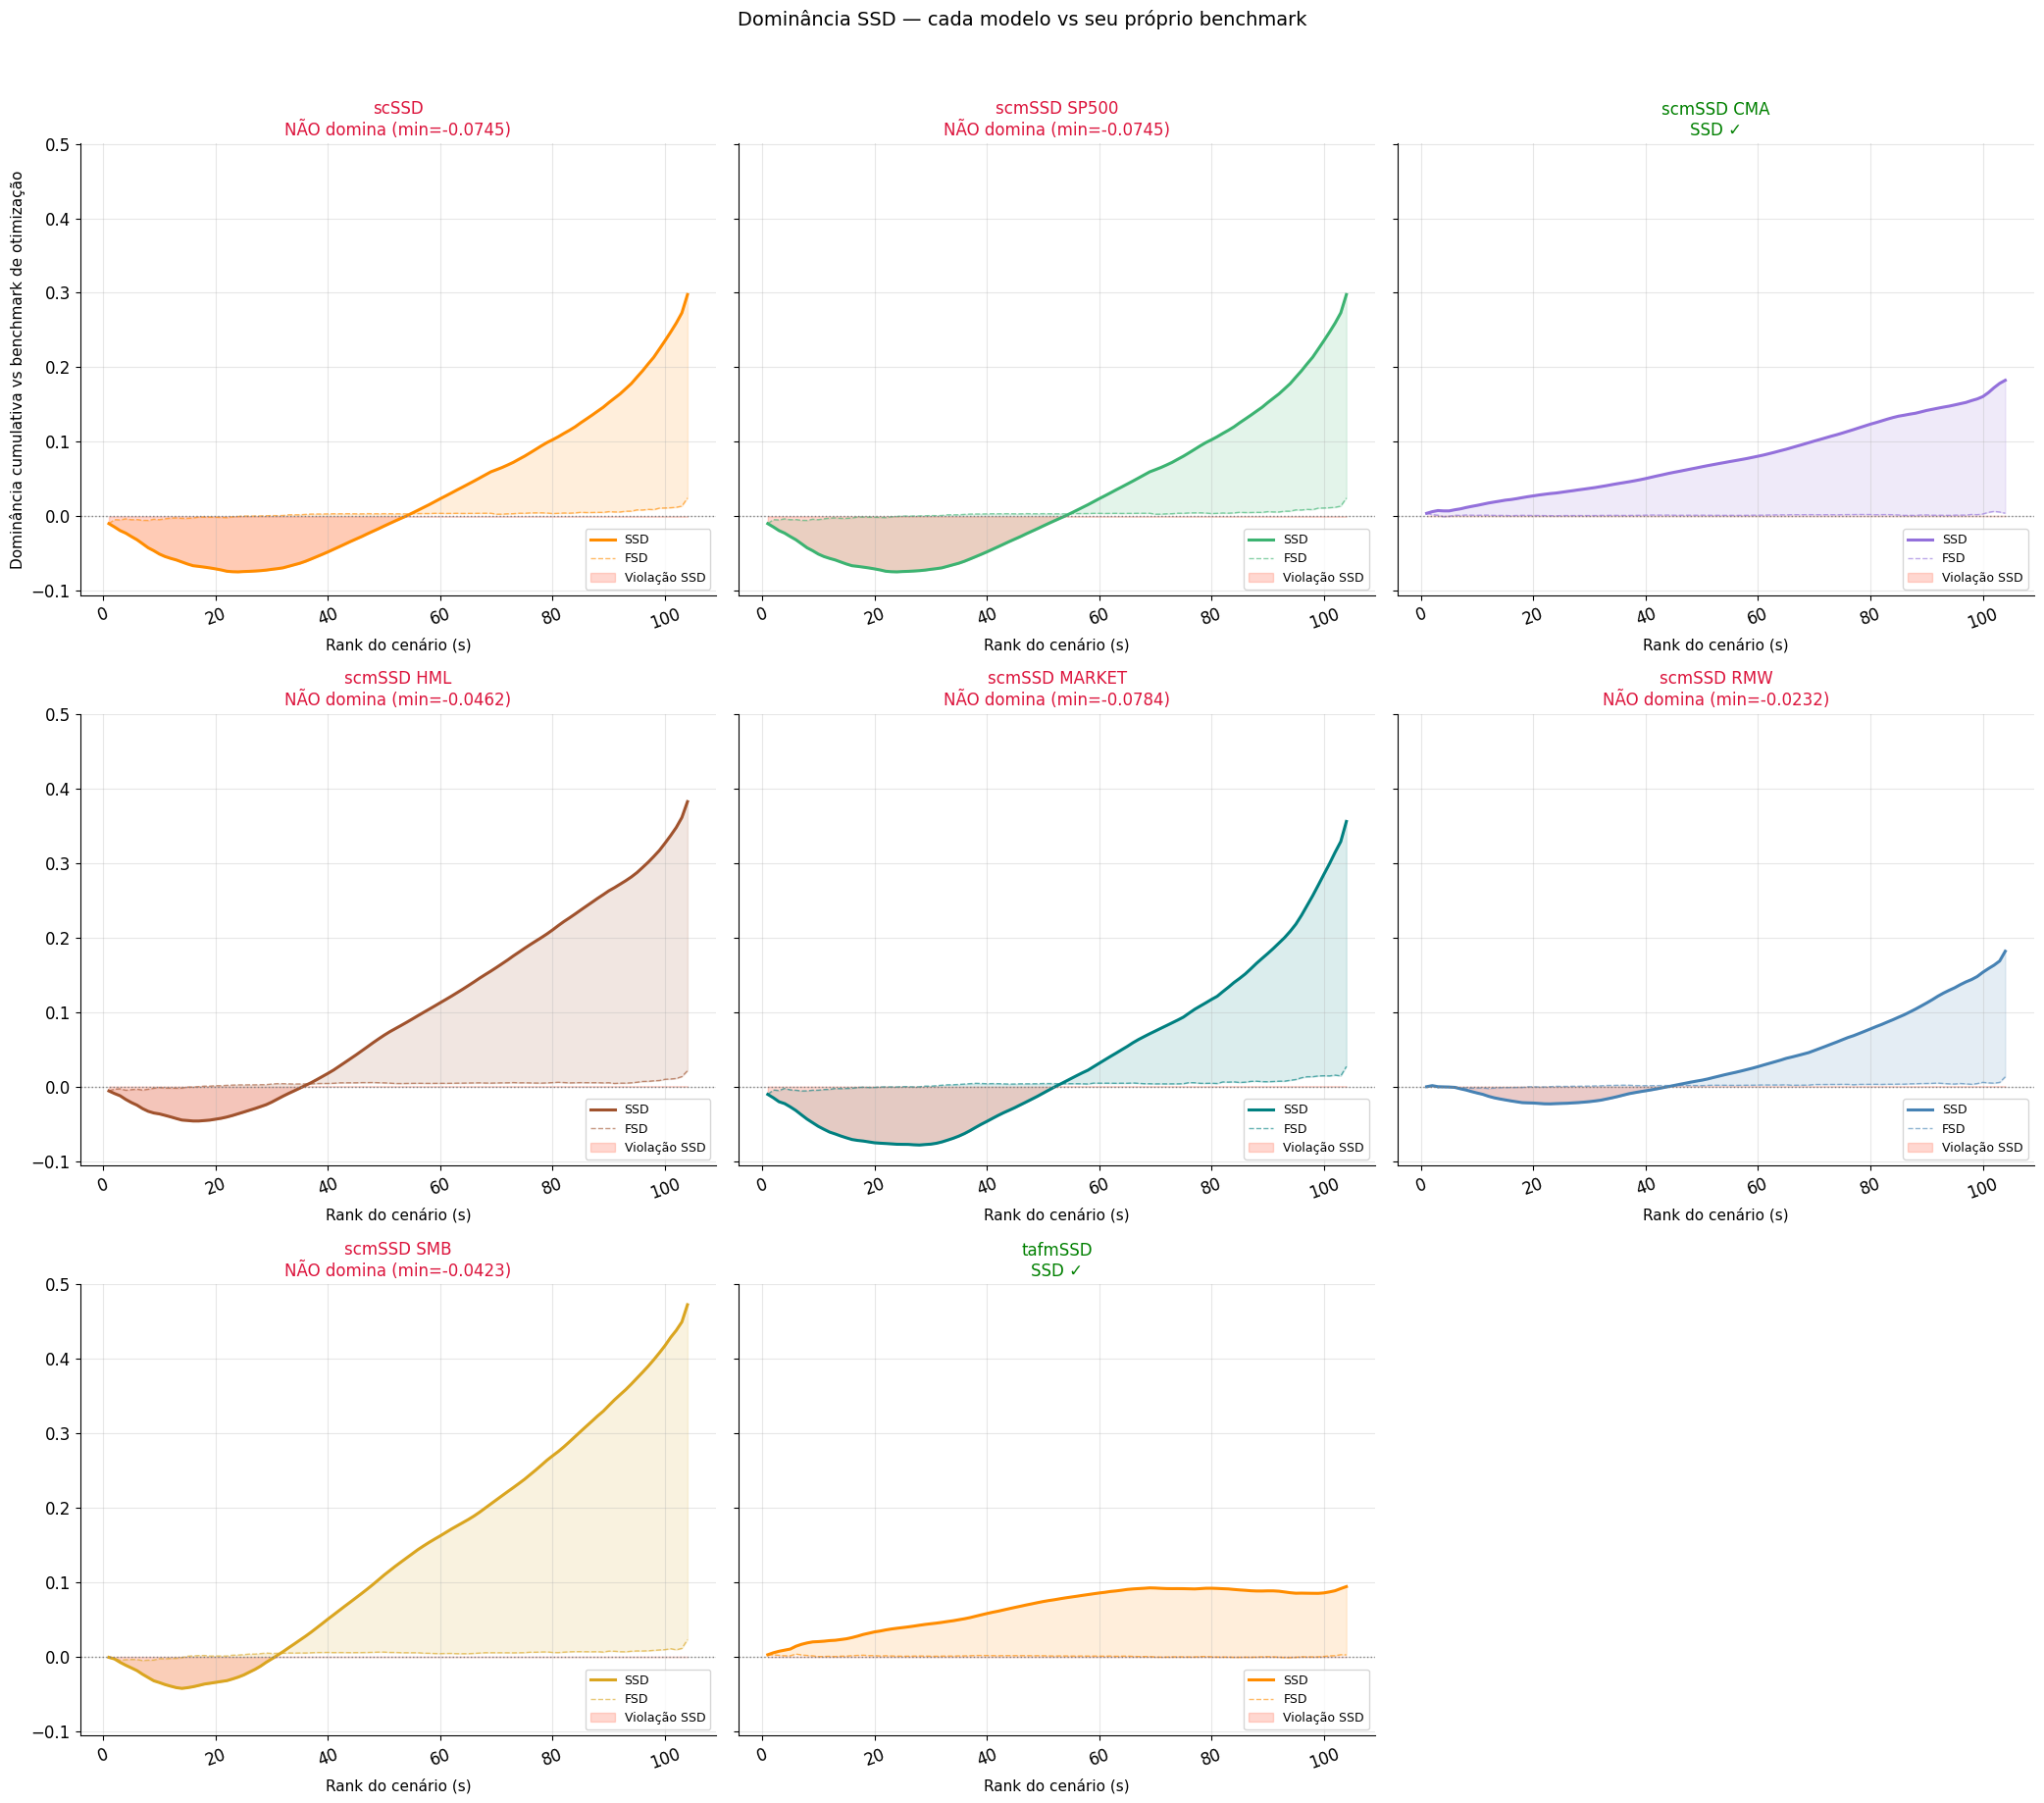

In [17]:
# Home dominance panels: one per model
plot_dominance_panels(
    home_dom, n_cols=3,
    benchmark_name='benchmark de otimização',
    title='Dominância SSD — cada modelo vs seu próprio benchmark',
    save_path=TAFMSSD_DIR / 'ssd_home_dominance.pdf',
)



=== tafmSSD: dominância cruzada vs cada benchmark individual ===
Benchmark     min(SSD)    min(FSD)  Status
--------------------------------------------------
  SP500        +0.002830   -0.001087  ✓ DOMINA
  CMA          -0.012385   -0.004066  ✗ VIOLA 
  HML          -0.000533   -0.001266  ✗ VIOLA 
  MARKET       +0.004124   -0.001197  ✓ DOMINA
  RMW          -0.010443   -0.002033  ✗ VIOLA 
  SMB          +0.011924   -0.002308  ✓ DOMINA
[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/ssd_cross_dominance_taf.pdf


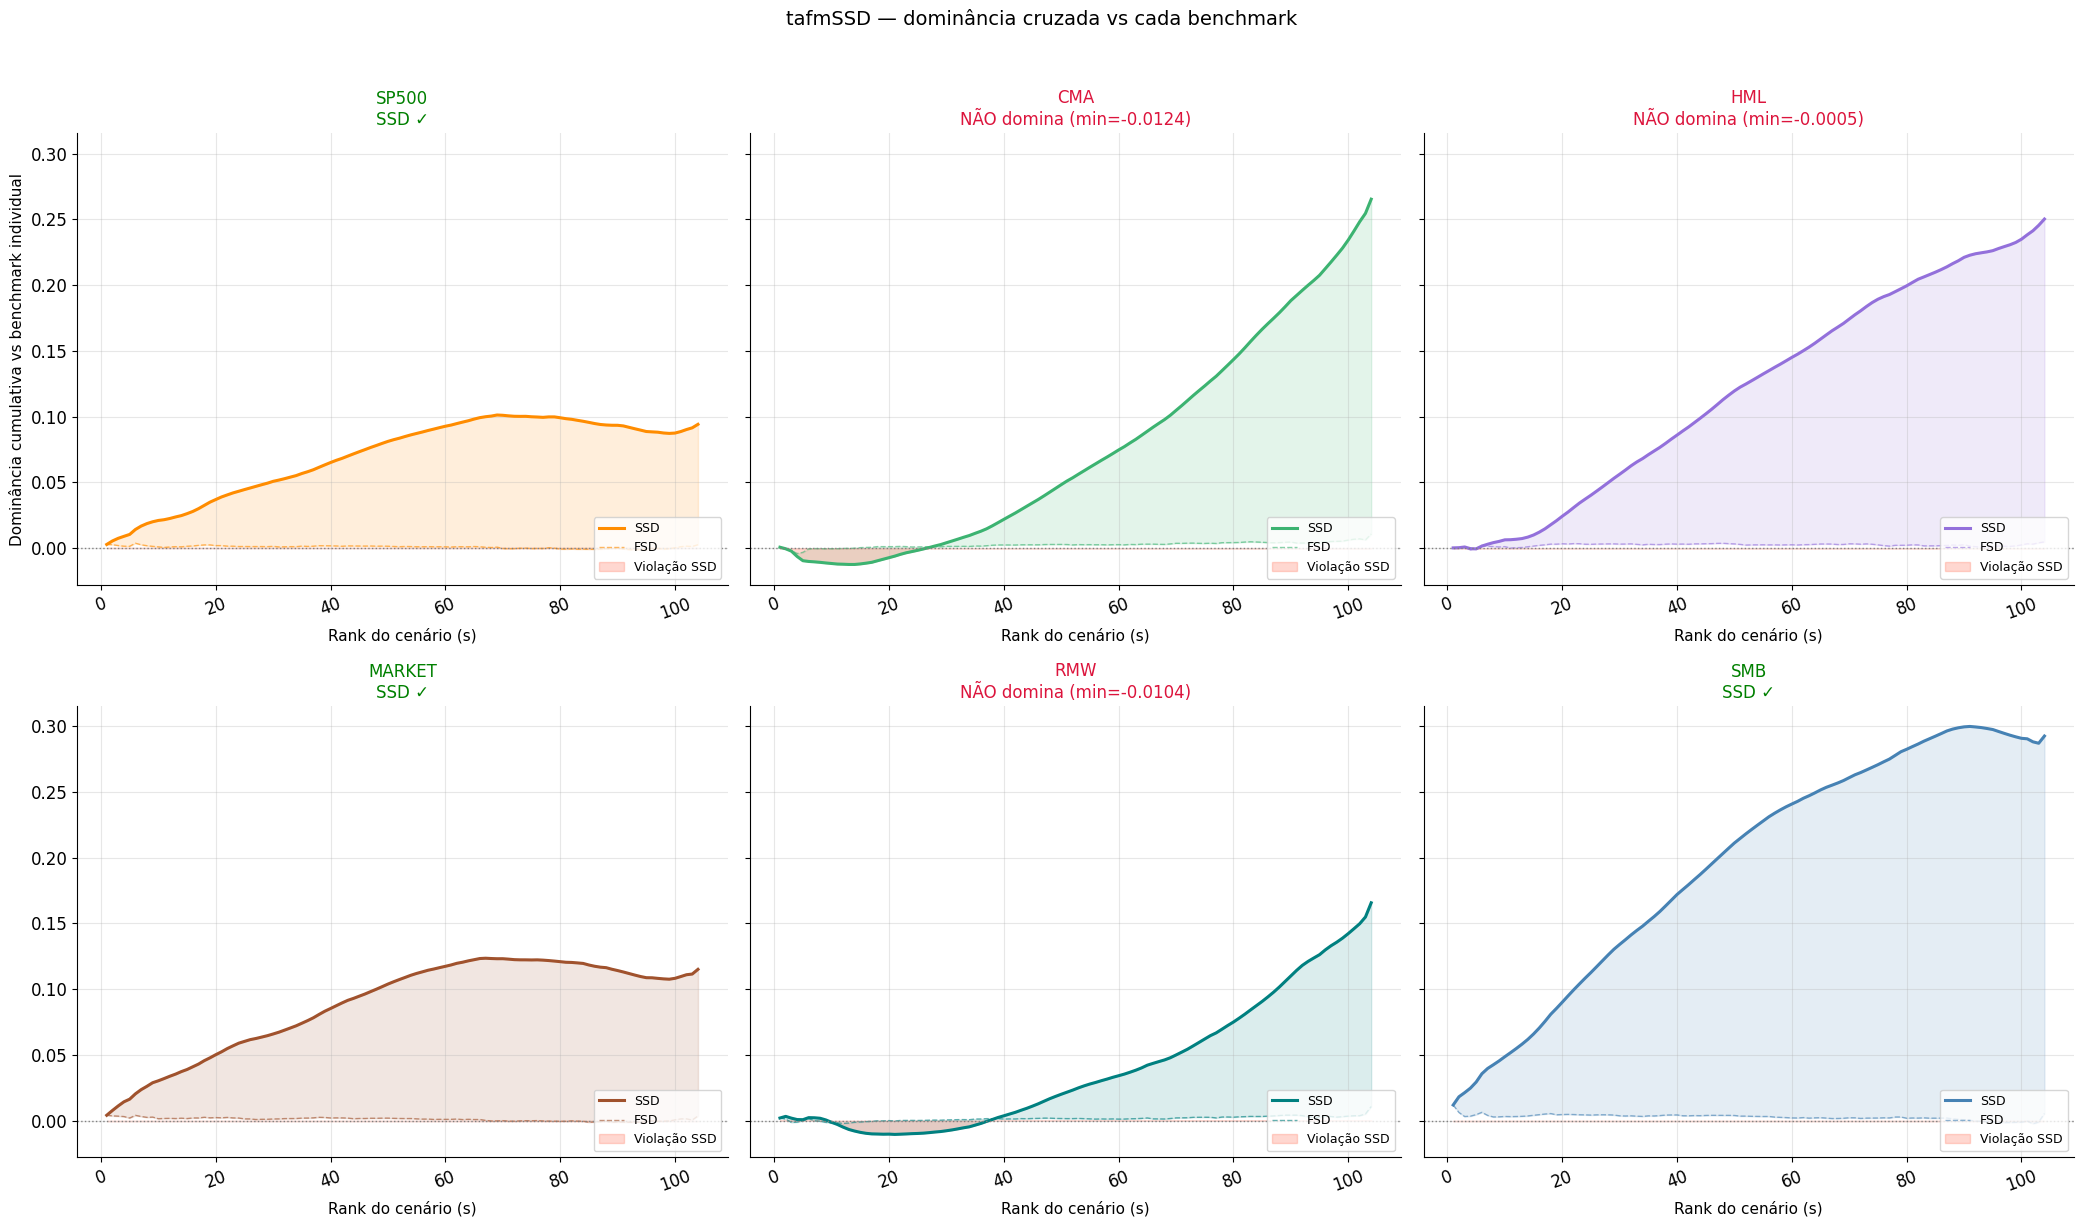

In [18]:
# Cross-dominance: tafmSSD vs all individual benchmarks
print('\n=== tafmSSD: dominância cruzada vs cada benchmark individual ===')
port_ret_taf = models['tafmSSD'].pct_change().dropna()
cross_dom    = {}

print(f'{"Benchmark":<10}  {"min(SSD)":>10}  {"min(FSD)":>10}  Status')
print('-' * 50)
for bench, d in bench_data.items():
    common = port_ret_taf.index.intersection(d['ret'].index)
    s, fsd, ssd = compute_ssd_dominance(
        port_ret_taf.loc[common].values, d['ret'].loc[common].values
    )
    cross_dom[bench] = (s, fsd, ssd)
    tag = '✓ DOMINA' if ssd.min() >= 0 else '✗ VIOLA '
    print(f'  {bench:<10}  {ssd.min():+10.6f}  {fsd.min():+10.6f}  {tag}')

plot_dominance_panels(
    cross_dom, n_cols=3,
    benchmark_name='benchmark individual',
    title='tafmSSD — dominância cruzada vs cada benchmark',
    save_path=TAFMSSD_DIR / 'ssd_cross_dominance_taf.pdf',
)


---
## 10. Análise risco × retorno — todos os modelos

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/risk_return_all_models.pdf


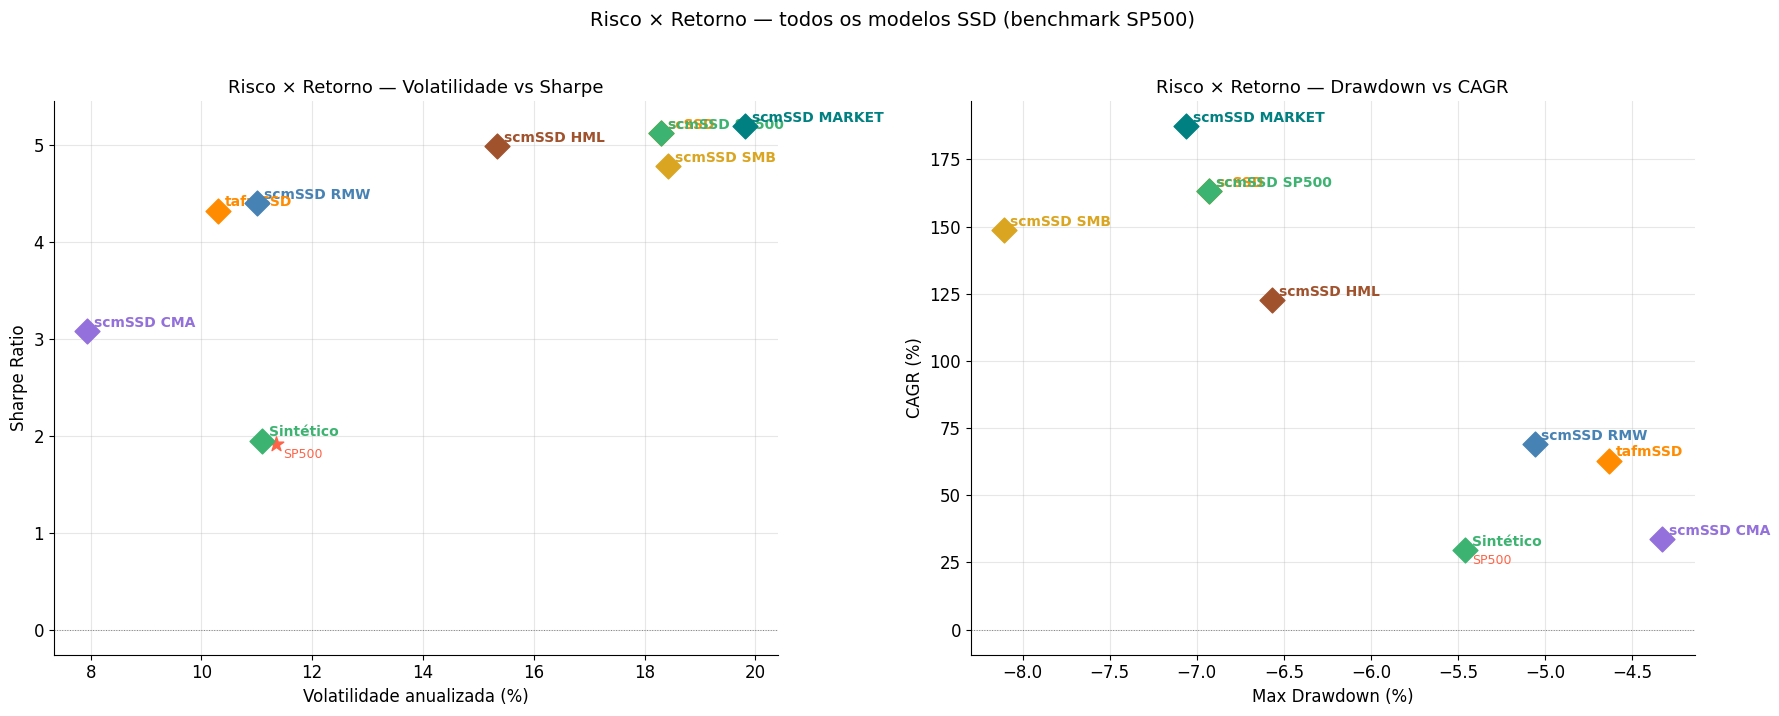

In [19]:
all_for_scatter = dict(models)
all_for_scatter['Sintético'] = synth_oos

plot_risk_return_scatter(
    all_for_scatter, sp500_norm,
    rf_annual=RISK_FREE,
    title='Risco × Retorno — todos os modelos SSD (benchmark SP500)',
    save_path=TAFMSSD_DIR / 'risk_return_all_models.pdf',
)


---
## 11. Distribuição de retornos e correlação

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/return_dist_scssd.pdf


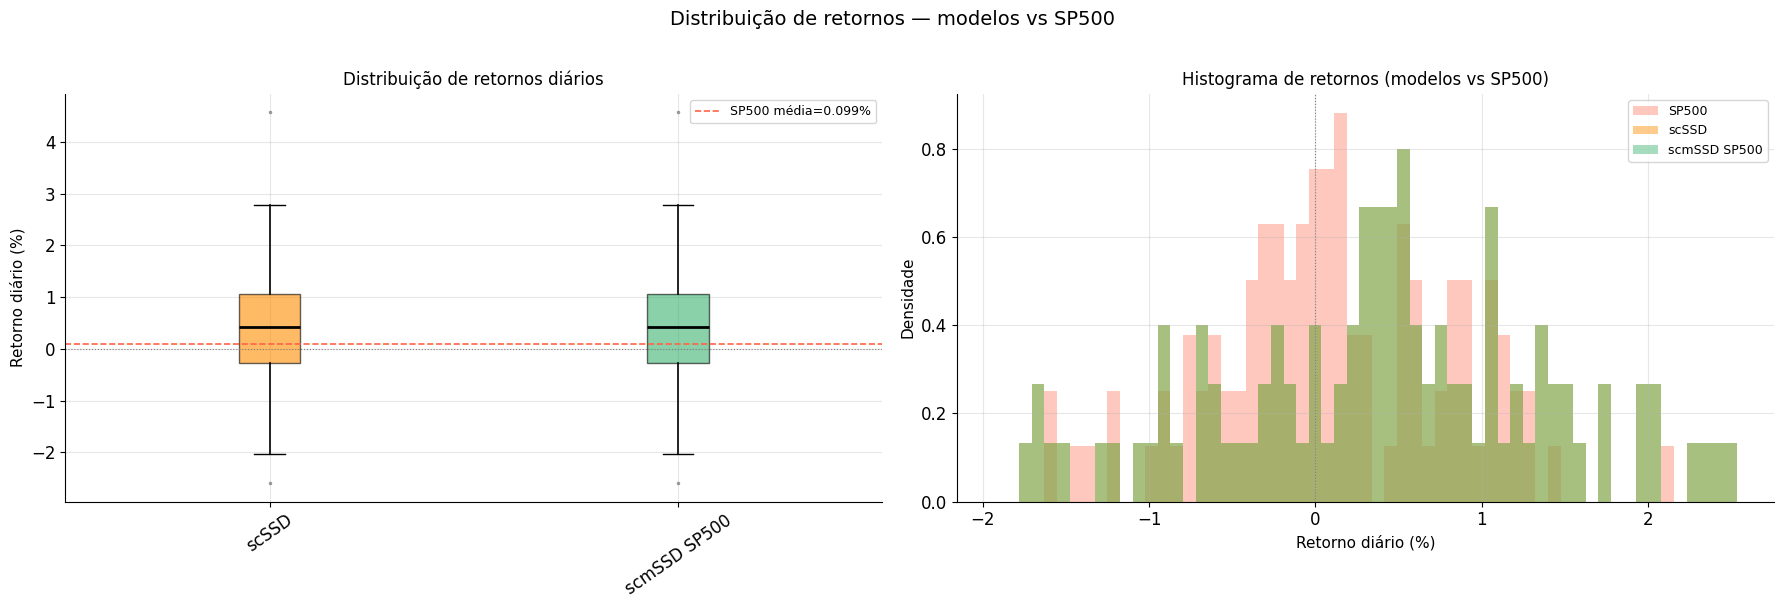

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/return_dist_scmssd.pdf


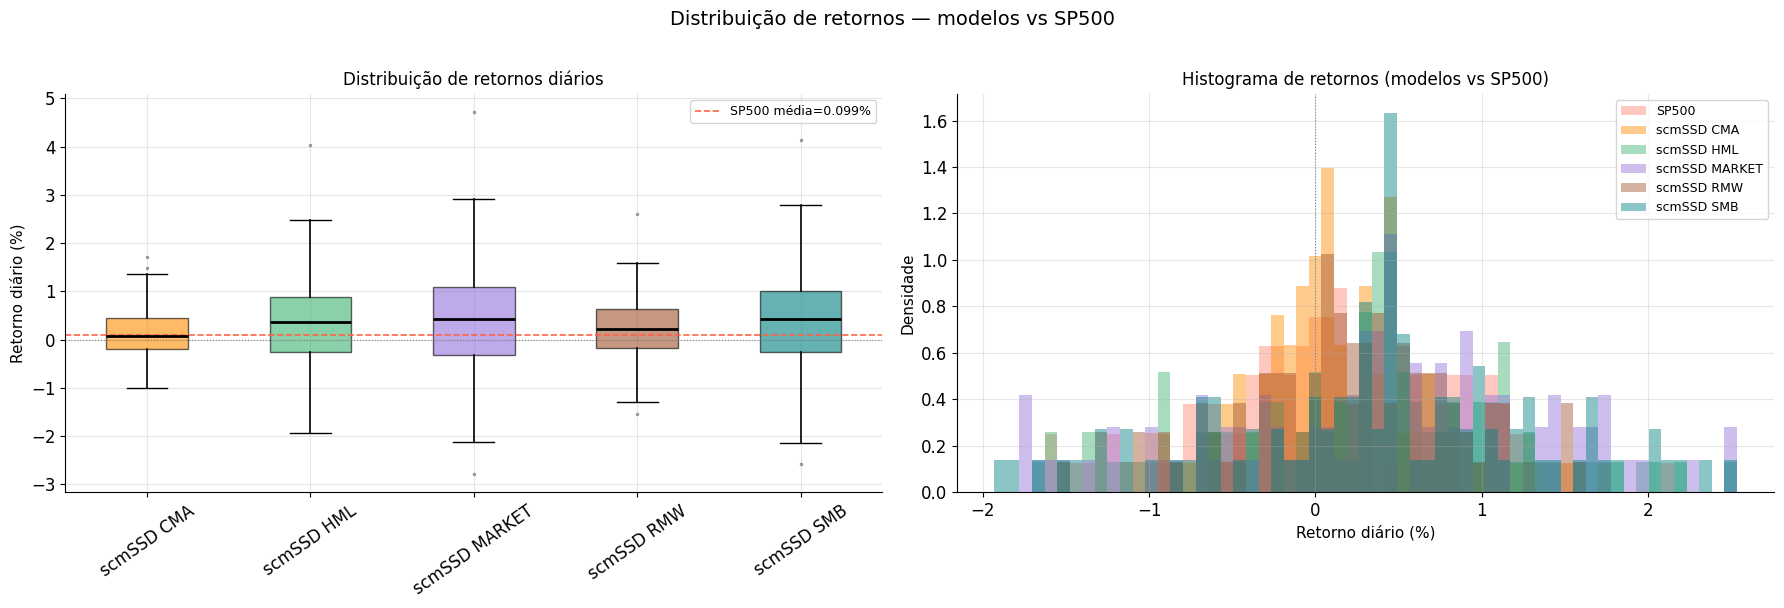

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/return_dist_tafmssd.pdf


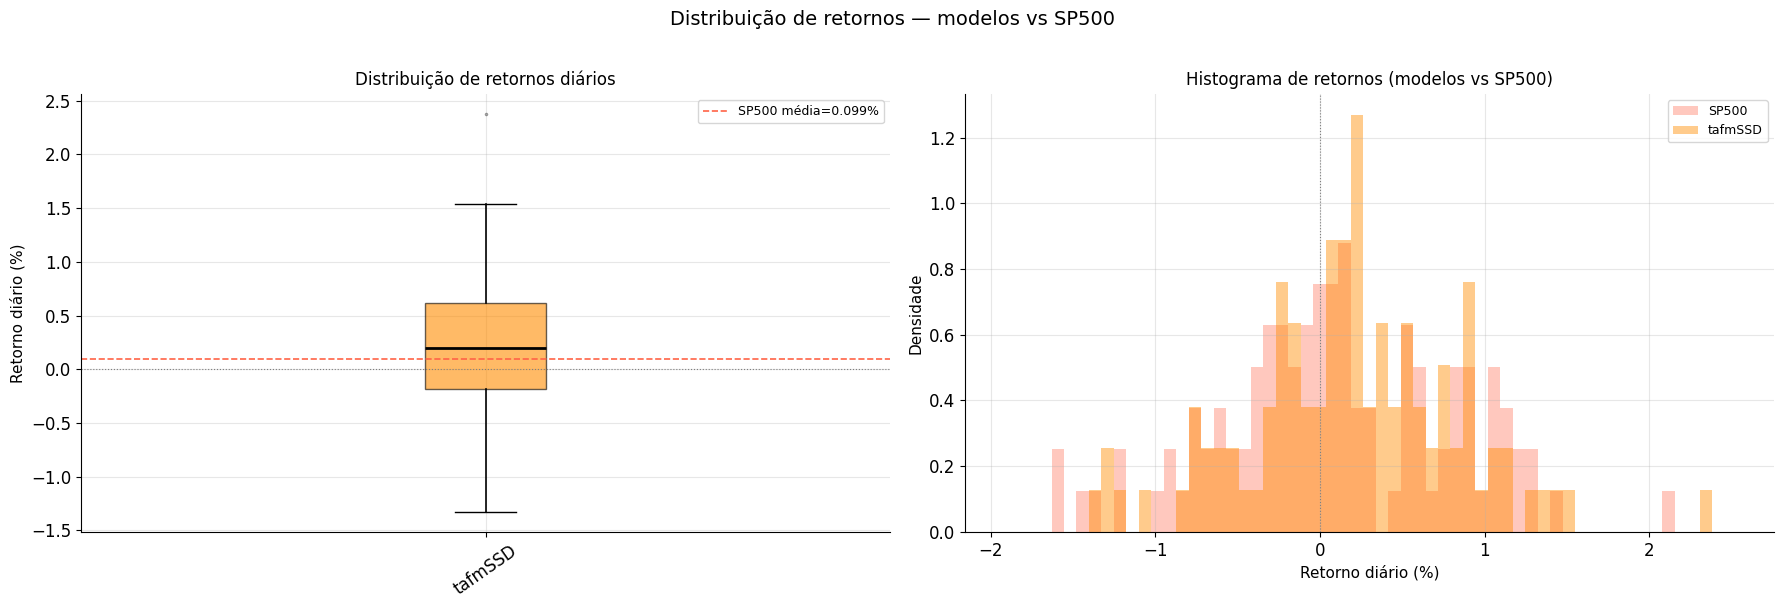

In [20]:
# Distribution: group by type
groups = {
    'scSSD (SP500-based)': {k: v for k, v in models.items()
                             if k in ('scSSD', 'scmSSD SP500')},
    'scmSSD (fatores)':    {k: v for k, v in models.items()
                             if k.startswith('scmSSD') and k != 'scmSSD SP500'},
    'tafmSSD':             {'tafmSSD': models['tafmSSD']},
}

for group_name, group_models in groups.items():
    if group_models:
        plot_return_distribution(
            group_models, bench_data['SP500']['ret'],
            highlight_keys=list(group_models.keys()),
            save_path=TAFMSSD_DIR / f'return_dist_{group_name.split("(")[0].strip().lower().replace(" ", "_")}.pdf',
        )


[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/correlation_all_models.pdf


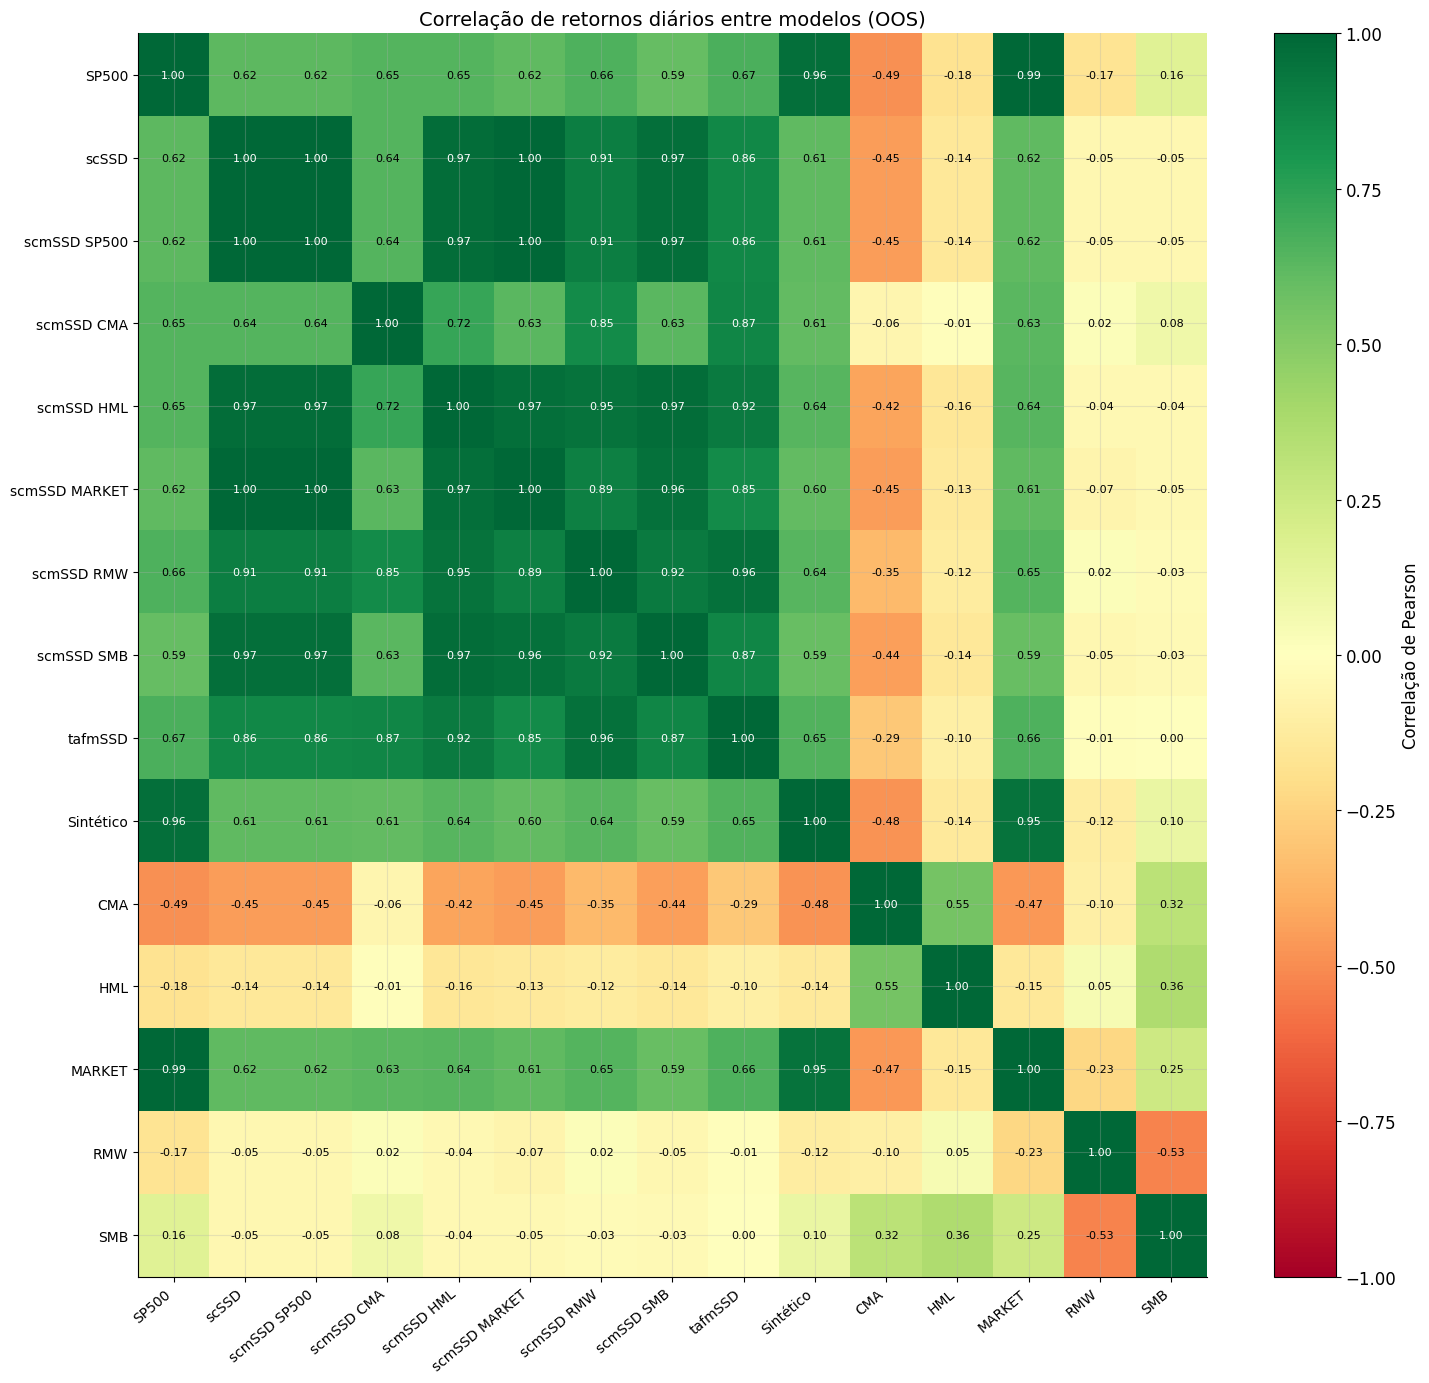

In [21]:
# Correlation matrix: all models + benchmarks
all_corr = {k: v for k, v in models.items()}
all_corr['Sintético'] = synth_oos
all_corr.update({b: d['norm'] for b, d in bench_data.items()})

plot_correlation_matrix(
    all_corr, bench_data['SP500']['ret'],
    benchmark_name='SP500',
    save_path=TAFMSSD_DIR / 'correlation_all_models.pdf',
)


---
## 12. Retornos em janela deslizante (21 dias)

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/rolling_sp500_group.pdf


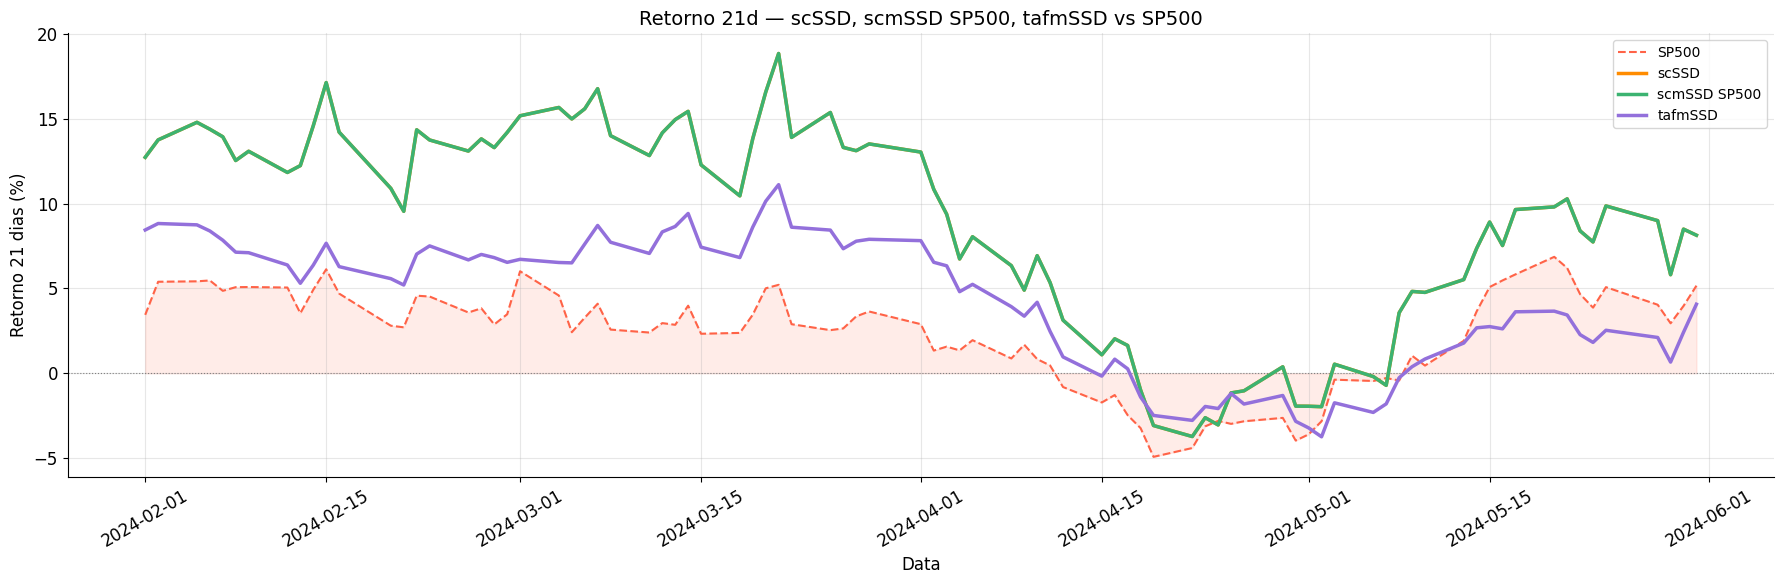

In [22]:
# Group 1: scSSD-based
rolling_g1 = {k: v for k, v in models.items() if 'SP500' in k or k == 'scSSD'}
rolling_g1['tafmSSD'] = models['tafmSSD']
plot_rolling_returns(
    rolling_g1, sp500_norm, window=21,
    title='Retorno 21d — scSSD, scmSSD SP500, tafmSSD vs SP500',
    save_path=TAFMSSD_DIR / 'rolling_sp500_group.pdf',
)


[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd/rolling_factor_group.pdf


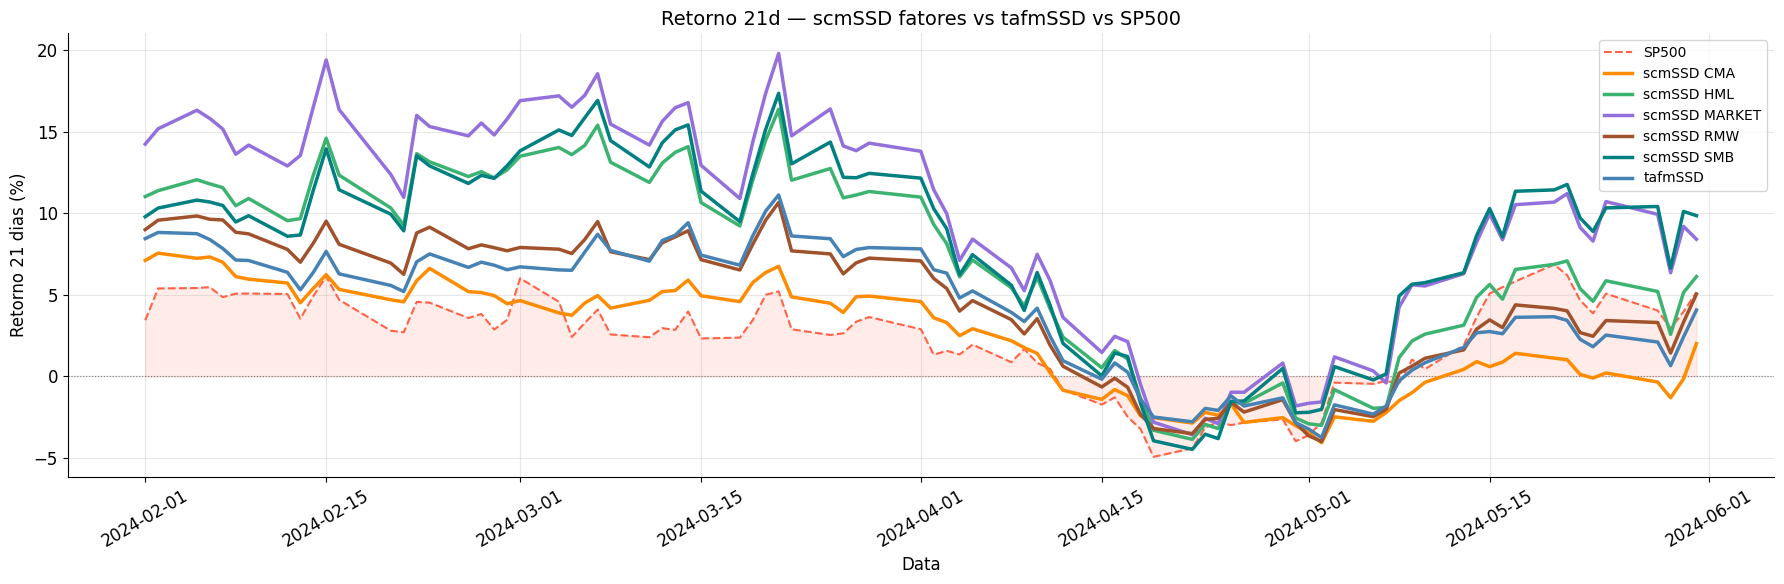

In [23]:
# Group 2: factor-based + tafmSSD
rolling_g2 = {k: v for k, v in models.items()
               if k.startswith('scmSSD') and k != 'scmSSD SP500'}
rolling_g2['tafmSSD'] = models['tafmSSD']
plot_rolling_returns(
    rolling_g2, sp500_norm, window=21,
    title='Retorno 21d — scmSSD fatores vs tafmSSD vs SP500',
    save_path=TAFMSSD_DIR / 'rolling_factor_group.pdf',
)


---
## 13. Sumário executivo

In [24]:
print('=' * 100)
print('  SUMÁRIO EXECUTIVO — tafmSSD e modelos da família SSD')
print(f'  Período OOS: {OOS_START} → {OOS_END}')
print('=' * 100)

m_sp = compute_metrics(sp500_norm, benchmark=sp500_norm, rf_annual=RISK_FREE)

hdr = (f"  {'Modelo':<24}  {'Final':>7}  {'CAGR':>8}  {'Vol':>7}  "
       f"{'Sharpe':>8}  {'Sortino':>9}  {'MaxDD':>8}  {'Beta':>7}")
print(hdr)
print('  ' + '-' * 90)

ref_row = (f"  {'SP500 (ref)':<24}  {m_sp['Final value']:>7.4f}  {m_sp['CAGR (%)']:>+7.2f}%  "
           f"{m_sp['Volatility (%)']:>6.2f}%  {m_sp['Sharpe Ratio']:>8.4f}  "
           f"{m_sp['Sortino Ratio']:>9.4f}  {m_sp['Max Drawdown (%)']:>+7.2f}%  {'1.0000':>7}")
print(ref_row)
print('  ' + '-' * 90)

order = ['scSSD', 'scmSSD SP500'] + [f'scmSSD {b}' for b in FACTOR_BENCHMARKS] + ['tafmSSD']
for label in order:
    if label not in models:
        continue
    m    = compute_metrics(models[label], benchmark=sp500_norm, rf_annual=RISK_FREE)
    beta = f"{m['Portfolio beta']:.4f}" if not pd.isna(m['Portfolio beta']) else '--'
    beat = ' ◄' if m['Sharpe Ratio'] > m_sp['Sharpe Ratio'] else ''
    row  = (f"  {label:<24}  {m['Final value']:>7.4f}  {m['CAGR (%)']:>+7.2f}%  "
            f"{m['Volatility (%)']:>6.2f}%  {m['Sharpe Ratio']:>8.4f}  "
            f"{m['Sortino Ratio']:>9.4f}  {m['Max Drawdown (%)']:>+7.2f}%  {beta:>7}{beat}")
    print(row)

print('=' * 100)


  SUMÁRIO EXECUTIVO — tafmSSD e modelos da família SSD
  Período OOS: 2024-01-01 → 2024-06-01
  Modelo                      Final      CAGR      Vol    Sharpe    Sortino     MaxDD     Beta
  ------------------------------------------------------------------------------------------
  SP500 (ref)                1.1127   +29.54%   11.34%    1.9096     3.5279    -5.46%   1.0000
  ------------------------------------------------------------------------------------------
  scSSD                      1.4911  +163.29%   18.29%    5.1260    15.2550    -6.93%   1.0043 ◄
  scmSSD SP500               1.4911  +163.29%   18.29%    5.1260    15.2550    -6.93%   1.0043 ◄
  scmSSD CMA                 1.1270   +33.59%    7.93%    3.0776     6.6670    -4.33%   0.4519 ◄
  scmSSD HML                 1.3917  +122.75%   15.33%    4.9903    13.6981    -6.57%   0.8740 ◄
  scmSSD MARKET              1.5458  +187.29%   19.81%    5.1909    16.2442    -7.06%   1.0749 ◄
  scmSSD RMW                 1.2423   +69.17%

In [25]:
print('\n' + '=' * 70)
print('  DOMINÂNCIA SSD — RESUMO (cada modelo vs seu benchmark)')
print('=' * 70)
print(f'  {"Modelo":<22}  {"Benchmark":<12}  {"min(SSD)":>10}  Status')
print('  ' + '-' * 60)

for label, (s, fsd, ssd) in home_dom.items():
    bench_name = label.replace('scmSSD ', '').replace('scSSD', 'SP500')
    if label == 'tafmSSD':
        bench_name = 'Sintético'
    tag = '✓ DOMINA' if ssd.min() >= 0 else '✗ VIOLA '
    print(f'  {label:<22}  {bench_name:<12}  {ssd.min():+10.6f}  {tag}')

print('=' * 70)



  DOMINÂNCIA SSD — RESUMO (cada modelo vs seu benchmark)
  Modelo                  Benchmark       min(SSD)  Status
  ------------------------------------------------------------
  scSSD                   SP500          -0.074537  ✗ VIOLA 
  scmSSD SP500            SP500          -0.074537  ✗ VIOLA 
  scmSSD CMA              CMA            +0.004033  ✓ DOMINA
  scmSSD HML              HML            -0.046201  ✗ VIOLA 
  scmSSD MARKET           MARKET         -0.078394  ✗ VIOLA 
  scmSSD RMW              RMW            -0.023199  ✗ VIOLA 
  scmSSD SMB              SMB            -0.042309  ✗ VIOLA 
  tafmSSD                 Sintético      +0.002830  ✓ DOMINA
